# insert liberaries

In [161]:
# import liberaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv('covid_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314946 entries, 0 to 314945
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    314946 non-null  object 
 1   continent                                   299979 non-null  object 
 2   location                                    314946 non-null  object 
 3   date                                        314946 non-null  object 
 4   total_cases                                 278750 non-null  float64
 5   new_cases                                   306117 non-null  float64
 6   new_cases_smoothed                          304853 non-null  float64
 7   total_deaths                                257954 non-null  float64
 8   new_deaths                                  306200 non-null  float64
 9   new_deaths_smoothed                         304970 non-null  float64
 

In [4]:
df_default = df

In [5]:
df.head

<bound method NDFrame.head of        iso_code continent     location        date  total_cases  new_cases  \
0           AFG      Asia  Afghanistan  2020-01-03          NaN        0.0   
1           AFG      Asia  Afghanistan  2020-01-04          NaN        0.0   
2           AFG      Asia  Afghanistan  2020-01-05          NaN        0.0   
3           AFG      Asia  Afghanistan  2020-01-06          NaN        0.0   
4           AFG      Asia  Afghanistan  2020-01-07          NaN        0.0   
...         ...       ...          ...         ...          ...        ...   
314941      ZWE    Africa     Zimbabwe  2023-05-27     264992.0        0.0   
314942      ZWE    Africa     Zimbabwe  2023-05-28     265023.0       31.0   
314943      ZWE    Africa     Zimbabwe  2023-05-29     265030.0        7.0   
314944      ZWE    Africa     Zimbabwe  2023-05-30     265030.0        0.0   
314945      ZWE    Africa     Zimbabwe  2023-05-31     265030.0        0.0   

        new_cases_smoothed  total

In [6]:


# يمكنك ضبط الحد الذي تعتبر بعده العمود "ضعيف البيانات"
threshold = 0.8   # أي إذا كان أكثر من 80% من العمود فارغ، نحذفه

# حساب نسبة القيم المفقودة في كل عمود
missing_ratios = df.isna().mean().sort_values(ascending=False)

# الأعمدة التي تتجاوز العتبة
to_drop = missing_ratios[missing_ratios > threshold].index.tolist()

# الأعمدة التي يُحتفظ بها
to_keep = missing_ratios[missing_ratios <= threshold].index.tolist()

print("🔎   total column count:", len(df.columns))
print("✅ column to keep:", len(to_keep))
print("❌ column to delete:", len(to_drop))
print("\n")

print("📉 الأعمدة المقترح حذفها (نسبة المفقود عالية):")
display(missing_ratios[missing_ratios > threshold].to_frame("missing_%"))

print("\n📈 الأعمدة التي تحتوي على بيانات كافية:")
display(missing_ratios[missing_ratios <= threshold].to_frame("missing_%"))

🔎   total column count: 67
✅ column to keep: 52
❌ column to delete: 15


📉 الأعمدة المقترح حذفها (نسبة المفقود عالية):


,missing_%
weekly_icu_admissions,0.969614
weekly_icu_admissions_per_million,0.969614
excess_mortality_cumulative_per_million,0.965305
excess_mortality,0.965305
excess_mortality_cumulative,0.965305
excess_mortality_cumulative_absolute,0.965305
weekly_hosp_admissions_per_million,0.929975
weekly_hosp_admissions,0.929975
icu_patients_per_million,0.884606
icu_patients,0.884606



📈 الأعمدة التي تحتوي على بيانات كافية:


,missing_%
people_fully_vaccinated,0.781385
people_fully_vaccinated_per_hundred,0.781385
people_vaccinated,0.770357
people_vaccinated_per_hundred,0.770357
new_tests,0.760584
new_tests_per_thousand,0.760584
total_vaccinations,0.760213
total_vaccinations_per_hundred,0.760213
total_tests,0.747935
total_tests_per_thousand,0.747935


In [7]:
df = df.dropna(how = 'all')
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314941,ZWE,Africa,Zimbabwe,2023-05-27,264992.0,0.0,9.429,5692.0,0.0,0.143,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
314942,ZWE,Africa,Zimbabwe,2023-05-28,265023.0,31.0,12.429,5693.0,1.0,0.286,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
314943,ZWE,Africa,Zimbabwe,2023-05-29,265030.0,7.0,13.000,5695.0,2.0,0.571,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN
314944,ZWE,Africa,Zimbabwe,2023-05-30,265030.0,0.0,13.000,5695.0,0.0,0.571,...,30.7,36.791,1.7,61.49,0.571,16320539.0,NaN,NaN,NaN,NaN


In [8]:
df['continent'].unique()

array(['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America',
       'South America'], dtype=object)

In [9]:
df['continent'].isna().sum()

np.int64(14967)

In [10]:
df[df['continent'].isna()].head(5000)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
1245,OWID_AFR,NaN,Africa,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
1246,OWID_AFR,NaN,Africa,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
1247,OWID_AFR,NaN,Africa,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
1248,OWID_AFR,NaN,Africa,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
1249,OWID_AFR,NaN,Africa,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.426737e+09,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119486,OWID_HIC,NaN,High income,2020-01-09,4.0,1.0,0.571,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.250515e+09,NaN,NaN,NaN,NaN
119487,OWID_HIC,NaN,High income,2020-01-10,4.0,0.0,0.571,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.250515e+09,NaN,NaN,NaN,NaN
119488,OWID_HIC,NaN,High income,2020-01-11,5.0,1.0,0.429,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.250515e+09,NaN,NaN,NaN,NaN
119489,OWID_HIC,NaN,High income,2020-01-12,6.0,1.0,0.571,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,1.250515e+09,NaN,NaN,NaN,NaN


In [11]:
df[df['continent'].isna()]['location'].unique()

array(['Africa', 'Asia', 'Europe', 'European Union', 'High income',
       'Low income', 'Lower middle income', 'North America', 'Oceania',
       'South America', 'Upper middle income', 'World'], dtype=object)

In [12]:
# عدد الصفوف قبل الحذف
before_rows = len(df)

# حذف الصفوف التي تحتوي على قيم مفقودة في عمود القارة
df = df.dropna(subset=['continent'])

# عدد الصفوف بعد الحذف
after_rows = len(df)

# حساب عدد الصفوف التي تم حذفها فعليًا
removed_rows = before_rows - after_rows

print(f"عدد الصفوف قبل الحذف: {before_rows}")
print(f"عدد الصفوف بعد الحذف: {after_rows}")
print(f"عدد الصفوف التي تم حذفها: {removed_rows}")
print(f"نسبة الصفوف المحذوفة: {(removed_rows / before_rows) * 100:.2f}%")

عدد الصفوف قبل الحذف: 314946
عدد الصفوف بعد الحذف: 299979
عدد الصفوف التي تم حذفها: 14967
نسبة الصفوف المحذوفة: 4.75%


In [13]:
df['continent'].value_counts()

continent
Africa           70966
Europe           68215
Asia             62425
North America    51053
Oceania          29881
South America    17439
Name: count, dtype: int64

In [14]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299979 entries, 0 to 314945
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    299979 non-null  object 
 1   continent                                   299979 non-null  object 
 2   location                                    299979 non-null  object 
 3   date                                        299979 non-null  object 
 4   total_cases                                 264028 non-null  float64
 5   new_cases                                   291177 non-null  float64
 6   new_cases_smoothed                          289973 non-null  float64
 7   total_deaths                                243484 non-null  float64
 8   new_deaths                                  291260 non-null  float64
 9   new_deaths_smoothed                         290090 non-null  float64
 10  t

In [16]:

df['date'] = pd.to_datetime(df['date'])

/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/3892224576.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'])


In [17]:
print("من:", df['date'].min())
print("إلى:", df['date'].max())

من: 2020-01-01 00:00:00
إلى: 2023-06-04 00:00:00


In [18]:
df.isna().sum().head(60)

iso_code                                           0
continent                                          0
location                                           0
date                                               0
total_cases                                    35951
new_cases                                       8802
new_cases_smoothed                             10006
total_deaths                                   56495
new_deaths                                      8719
new_deaths_smoothed                             9889
total_cases_per_million                        35951
new_cases_per_million                           8802
new_cases_smoothed_per_million                 10006
total_deaths_per_million                       56495
new_deaths_per_million                          8719
new_deaths_smoothed_per_million                 9889
reproduction_rate                             116238
icu_patients                                  263636
icu_patients_per_million                      

In [19]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
)
missing['missing_%'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing.sort_values('missing_%', ascending=False)
missing.head(50)

,missing_count,missing_%
weekly_icu_admissions,290409,96.8
weekly_icu_admissions_per_million,290409,96.8
excess_mortality_cumulative_absolute,289052,96.4
excess_mortality_cumulative_per_million,289052,96.4
excess_mortality_cumulative,289052,96.4
excess_mortality,289052,96.4
weekly_hosp_admissions_per_million,277925,92.6
weekly_hosp_admissions,277925,92.6
total_boosters,265411,88.5
total_boosters_per_hundred,265411,88.5


In [20]:
df = df.loc[:, df.isna().mean() < 0.6]
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index,population
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314941,ZWE,Africa,Zimbabwe,2023-05-27,264992.0,0.0,9.429,5692.0,0.0,0.143,...,1899.775,21.4,307.846,1.82,1.6,30.7,1.7,61.49,0.571,16320539.0
314942,ZWE,Africa,Zimbabwe,2023-05-28,265023.0,31.0,12.429,5693.0,1.0,0.286,...,1899.775,21.4,307.846,1.82,1.6,30.7,1.7,61.49,0.571,16320539.0
314943,ZWE,Africa,Zimbabwe,2023-05-29,265030.0,7.0,13.000,5695.0,2.0,0.571,...,1899.775,21.4,307.846,1.82,1.6,30.7,1.7,61.49,0.571,16320539.0
314944,ZWE,Africa,Zimbabwe,2023-05-30,265030.0,0.0,13.000,5695.0,0.0,0.571,...,1899.775,21.4,307.846,1.82,1.6,30.7,1.7,61.49,0.571,16320539.0


In [21]:
print("عدد الأعمدة بعد الحذف:", df.shape[1])
print("عدد الصفوف:", df.shape[0])

عدد الأعمدة بعد الحذف: 36
عدد الصفوف: 299979


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299979 entries, 0 to 314945
Data columns (total 36 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 264028 non-null  float64       
 5   new_cases                                   291177 non-null  float64       
 6   new_cases_smoothed                          289973 non-null  float64       
 7   total_deaths                                243484 non-null  float64       
 8   new_deaths                                  291260 non-null  float64       
 9 

In [23]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
)
missing['missing_%'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing.sort_values('missing_%', ascending=False)
missing.head(30)

,missing_count,missing_%
extreme_poverty,144307,48.1
new_vaccinations_smoothed_per_million,140956,47.0
new_people_vaccinated_smoothed_per_hundred,141123,47.0
new_people_vaccinated_smoothed,141123,47.0
new_vaccinations_smoothed,140956,47.0
male_smokers,120636,40.2
female_smokers,118145,39.4
reproduction_rate,116238,38.7
stringency_index,102328,34.1
hospital_beds_per_thousand,85775,28.6


In [24]:
df[df['total_cases'].isna()].head(25)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index,population
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
5,AFG,Asia,Afghanistan,2020-01-08,NaN,0.0,0.0,NaN,0.0,0.0,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
6,AFG,Asia,Afghanistan,2020-01-09,NaN,0.0,0.0,NaN,0.0,0.0,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
7,AFG,Asia,Afghanistan,2020-01-10,NaN,0.0,0.0,NaN,0.0,0.0,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
8,AFG,Asia,Afghanistan,2020-01-11,NaN,0.0,0.0,NaN,0.0,0.0,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0
9,AFG,Asia,Afghanistan,2020-01-12,NaN,0.0,0.0,NaN,0.0,0.0,...,1803.987,NaN,597.029,9.59,NaN,NaN,0.5,64.83,0.511,41128772.0


In [25]:
missing_by_country = (
    df.groupby('location')['total_cases']
      .apply(lambda x: x.isna().sum())
      .reset_index(name='missing_total_cases')
      .sort_values('missing_total_cases', ascending=False)
)

missing_by_country.head(50)  # عرض أول 20 دولة فيها أكبر عدد من القيم المفقودة

,location,missing_total_cases
155,North Korea,1245
222,Turkmenistan,1245
93,Hong Kong,1214
211,Taiwan,1198
158,Northern Ireland,1187
190,Scotland,1179
62,England,1161
237,Wales,1156
217,Tokelau,1074
180,Saint Helena,948


In [26]:
df[df['location'] == 'Afghanistan'][['date', 'total_cases']].head(50)

,date,total_cases
0,2020-01-03,NaN
1,2020-01-04,NaN
2,2020-01-05,NaN
3,2020-01-06,NaN
4,2020-01-07,NaN
5,2020-01-08,NaN
6,2020-01-09,NaN
7,2020-01-10,NaN
8,2020-01-11,NaN
9,2020-01-12,NaN


In [27]:
afg = df[df['location'] == 'Afghanistan'][['date', 'total_cases']]
afg

,date,total_cases
0,2020-01-03,NaN
1,2020-01-04,NaN
2,2020-01-05,NaN
3,2020-01-06,NaN
4,2020-01-07,NaN
...,...,...
1240,2023-05-27,221167.0
1241,2023-05-28,221180.0
1242,2023-05-29,221332.0
1243,2023-05-30,221332.0


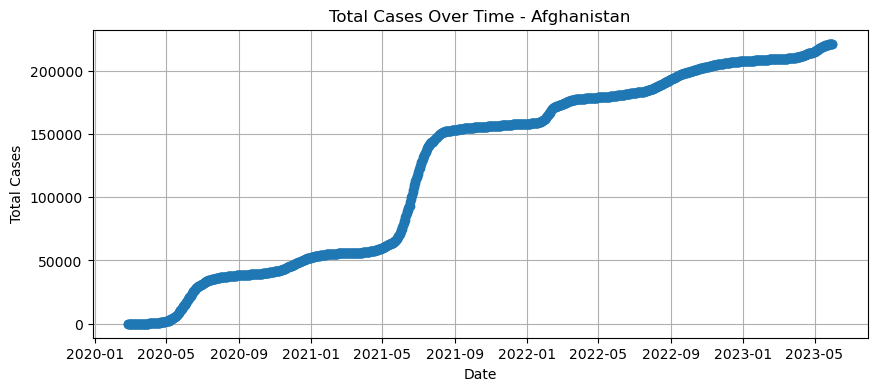

In [28]:

afg = df[df['location'] == 'Afghanistan']
plt.figure(figsize=(10,4))
plt.plot(afg['date'], afg['total_cases'], marker='o', linestyle='-')
plt.title('Total Cases Over Time - Afghanistan')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)
plt.show()

In [29]:
df = df.sort_values(['location','date']).reset_index(drop=True)

In [30]:

def fill_cumulative(series: pd.Series) -> pd.Series:
    s = series.copy()
    # تحديد كل المواقع من أول قيمة غير مفقودة فصاعدًا
    seen = s.notna().cummax()
    # ما قبل أول قيمة غير مفقودة (seen == False) نجعله صفرًا
    s[~seen] = 0
    # أي فراغات لاحقة نملؤها بالقيمة السابقة
    s = s.ffill()
    # لو السلسلة كلها NaN نجعلها 0 كلها
    s = s.fillna(0)
    return s

In [31]:
df['total_cases'] = (
    df.groupby('location')['total_cases']
      .transform(fill_cumulative)
)

In [32]:
df[df['location'] == 'Afghanistan'][['date', 'total_cases']].iloc[75:100]

,date,total_cases
75,2020-03-18,22.0
76,2020-03-19,22.0
77,2020-03-20,22.0
78,2020-03-21,22.0
79,2020-03-22,24.0
80,2020-03-23,24.0
81,2020-03-24,40.0
82,2020-03-25,42.0
83,2020-03-26,74.0
84,2020-03-27,74.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299979 entries, 0 to 299978
Data columns (total 36 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 299979 non-null  float64       
 5   new_cases                                   291177 non-null  float64       
 6   new_cases_smoothed                          289973 non-null  float64       
 7   total_deaths                                243484 non-null  float64       
 8   new_deaths                                  291260 non-null  float64      

In [34]:
import numpy as np

# تأكد من الترتيب الزمني داخل كل دولة
df = df.sort_values(['location','date']).reset_index(drop=True)

# دالة معالجة التراكميات: البداية = 0 ثم ملء الفجوات بالقيمة السابقة
def fill_cumulative(series: pd.Series) -> pd.Series:
    s = series.copy()
    # كل ما قبل أول قيمة معروفة يصبح 0
    seen = s.notna().cummax()
    s[~seen] = 0
    # ملء الفجوات اللاحقة بالقيمة السابقة
    s = s.ffill()
    # لو السلسلة كلها NaN اجعلها 0
    s = s.fillna(0)
    return s

# الأعمدة التراكمية التي نريد معالجتها (اختر الموجود فقط)
cum_cols = [c for c in [
    'total_cases','total_deaths','total_tests',
    'total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','total_boosters'
] if c in df.columns]

for col in cum_cols:
    df[col] = df.groupby('location')[col].transform(fill_cumulative)

In [35]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(['location','date']).reset_index(drop=True)

In [36]:
def fill_cumulative(s: pd.Series) -> pd.Series:
    s = s.copy()
    # كل ما قبل أول قيمة معروفة = 0
    seen = s.notna().cummax()
    s[~seen] = 0
    # ملء الفجوات اللاحقة بالقيمة السابقة
    s = s.ffill()
    # فرض أن السلسلة غير تناقصية
    s = s.cummax()
    # لو السلسلة كلها NaN اجعلها 0
    s = s.fillna(0)
    return s

In [37]:
cum_cols = [c for c in [
    'total_cases','total_deaths','total_tests',
    'total_vaccinations','people_vaccinated',
    'people_fully_vaccinated','total_boosters'
] if c in df.columns]

for c in cum_cols:
    df[c] = df.groupby('location')[c].transform(fill_cumulative)

In [38]:
# لا توجد قيم مفقودة
print({c: int(df[c].isna().sum()) for c in cum_cols})

# عدد “الخطوات السالبة” (يجب أن يكون 0 لكل عمود)
def count_negative_steps(dframe, col):
    g = (dframe.sort_values(['location','date'])
                 .groupby('location')[col])
    return int(g.apply(lambda s: (s.diff() < 0).sum()).sum())

for c in cum_cols:
    print(c, "negative_steps =", count_negative_steps(df, c))

{'total_cases': 0, 'total_deaths': 0}
total_cases negative_steps = 0
total_deaths negative_steps = 0


In [39]:
afg = df[df['location']=='Afghanistan'][['date'] + cum_cols].copy()
afg['diff_total_cases'] = afg['total_cases'].diff()
afg.head(15)          # أول 15 صفًا بعد المعالجة
afg[afg['diff_total_cases'] < 0]  # يجب أن تكون فارغة

,date,total_cases,total_deaths,diff_total_cases


In [40]:

# تأكد من الترتيب الزمني
df = df.sort_values(['location','date']).reset_index(drop=True)

# (عمود تراكمي -> عمود يومي) خرائط
pairs = [
    ('total_cases',         'new_cases'),
    ('total_deaths',        'new_deaths'),
    ('total_tests',         'new_tests'),
    ('total_vaccinations',  'new_vaccinations')
]

for total_col, new_col in pairs:
    if total_col in df.columns:
        # اشتقاق اليومي من التراكمي داخل كل دولة
        derived = (df.groupby('location')[total_col]
                     .diff()
                     .clip(lower=0))  # لا سماح بالسالب
        if new_col in df.columns:
            # استخدم المشتق لتعويض القيم المفقودة أو القيم السالبة
            base = df[new_col].copy()
            base = base.mask(base.isna(), derived)         # ملء NaN من المشتق
            base = base.mask(base < 0, 0)                  # قصّ السالب إلى 0
            # لو ظلّت NaN (نادرًا)، املأها من المشتق أو 0
            base = base.fillna(derived).fillna(0)
            df[new_col] = base
        else:
            # إن لم يوجد العمود اليومي أصلًا، أنشئه من المشتق
            df[new_col] = derived.fillna(0)
    else:
        # لا يوجد تراكمي: لو العمود اليومي موجود املأ الفراغات بـ 0
        if new_col in df.columns:
            df[new_col] = df[new_col].fillna(0)

In [41]:
def check_daily(df, total_col, new_col):
    out = {}

    # 1) لا قيم مفقودة
    out['nan_count'] = int(df[new_col].isna().sum())

    # 2) لا قيم سالبة
    out['neg_count'] = int((df[new_col] < 0).sum())

    # 3) التطابق مع مشتق التراكمي (إن وُجد التراكمي)
    if total_col in df.columns:
        derived = (df.groupby('location')[total_col].diff().clip(lower=0))
        # الفرق المطلق بين الموجود والمشتق (نهمل NaN بالمقارنة)
        diff_abs = (df[new_col].fillna(0) - derived.fillna(0)).abs()
        # اسمح بفروق طفيفة جدًا من النوع العائم
        out['mismatch_rows'] = int((diff_abs > 1e-9).sum())
    else:
        out['mismatch_rows'] = None

    return out

pairs = [
    ('total_cases',         'new_cases'),
    ('total_deaths',        'new_deaths'),
    ('total_tests',         'new_tests'),
    ('total_vaccinations',  'new_vaccinations')
]

for total_col, new_col in pairs:
    if new_col in df.columns:
        res = check_daily(df, total_col, new_col)
        print(f"{new_col}: ", res)

# معاينة سريعة لدولة مثال
country = "Afghanistan"
cols_to_show = [c for c in ['date','total_cases','new_cases',
                            'total_deaths','new_deaths',
                            'total_tests','new_tests',
                            'total_vaccinations','new_vaccinations'] if c in df.columns]
display(df[df['location']==country][cols_to_show].head(15))

new_cases:  {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 209}
new_deaths:  {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 53}


,date,total_cases,new_cases,total_deaths,new_deaths
0,2020-01-03,0.0,0.0,0.0,0.0
1,2020-01-04,0.0,0.0,0.0,0.0
2,2020-01-05,0.0,0.0,0.0,0.0
3,2020-01-06,0.0,0.0,0.0,0.0
4,2020-01-07,0.0,0.0,0.0,0.0
5,2020-01-08,0.0,0.0,0.0,0.0
6,2020-01-09,0.0,0.0,0.0,0.0
7,2020-01-10,0.0,0.0,0.0,0.0
8,2020-01-11,0.0,0.0,0.0,0.0
9,2020-01-12,0.0,0.0,0.0,0.0


In [42]:
# إزالة أي صفوف مكررة على مستوى (location, date) بالإبقاء على آخر ظهور
df = df.sort_values(['location','date']).drop_duplicates(['location','date'], keep='last').reset_index(drop=True)

In [43]:
def check_daily(df, total_col, new_col):
    out = {}

    # 1) لا قيم مفقودة
    out['nan_count'] = int(df[new_col].isna().sum())

    # 2) لا قيم سالبة
    out['neg_count'] = int((df[new_col] < 0).sum())

    # 3) التطابق مع مشتق التراكمي (إن وُجد التراكمي)
    if total_col in df.columns:
        derived = (df.groupby('location')[total_col].diff().clip(lower=0))
        # الفرق المطلق بين الموجود والمشتق (نهمل NaN بالمقارنة)
        diff_abs = (df[new_col].fillna(0) - derived.fillna(0)).abs()
        # اسمح بفروق طفيفة جدًا من النوع العائم
        out['mismatch_rows'] = int((diff_abs > 1e-9).sum())
    else:
        out['mismatch_rows'] = None

    return out

pairs = [
    ('total_cases',         'new_cases'),
    ('total_deaths',        'new_deaths'),
    ('total_tests',         'new_tests'),
    ('total_vaccinations',  'new_vaccinations')
]

for total_col, new_col in pairs:
    if new_col in df.columns:
        res = check_daily(df, total_col, new_col)
        print(f"{new_col}: ", res)

# معاينة سريعة لدولة مثال
country = "Afghanistan"
cols_to_show = [c for c in ['date','total_cases','new_cases',
                            'total_deaths','new_deaths',
                            'total_tests','new_tests',
                            'total_vaccinations','new_vaccinations'] if c in df.columns]
display(df[df['location']==country][cols_to_show].head(15))

new_cases:  {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 209}
new_deaths:  {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 53}


,date,total_cases,new_cases,total_deaths,new_deaths
0,2020-01-03,0.0,0.0,0.0,0.0
1,2020-01-04,0.0,0.0,0.0,0.0
2,2020-01-05,0.0,0.0,0.0,0.0
3,2020-01-06,0.0,0.0,0.0,0.0
4,2020-01-07,0.0,0.0,0.0,0.0
5,2020-01-08,0.0,0.0,0.0,0.0
6,2020-01-09,0.0,0.0,0.0,0.0
7,2020-01-10,0.0,0.0,0.0,0.0
8,2020-01-11,0.0,0.0,0.0,0.0
9,2020-01-12,0.0,0.0,0.0,0.0


In [44]:
# تأكد من الترتيب ونوع التاريخ
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(['location','date']).drop_duplicates(['location','date'], keep='last').reset_index(drop=True)

pairs = [
    ('total_cases',         'new_cases'),
    ('total_deaths',        'new_deaths'),
    ('total_tests',         'new_tests'),
    ('total_vaccinations',  'new_vaccinations'),
]

for total_col, new_col in pairs:
    if total_col in df.columns:
        # اشتقاق اليومي من التراكمي داخل كل دولة
        daily = (df.groupby('location')[total_col].diff()
                   .clip(lower=0)         # لا قيم سالبة
                   .fillna(0))            # أول يوم في كل دولة
        df[new_col] = daily                # استبدال كامل لضمان التطابق

In [45]:
def check_daily(df, total_col, new_col):
    out = {}
    out['nan_count'] = int(df[new_col].isna().sum())
    out['neg_count'] = int((df[new_col] < 0).sum())
    if total_col in df.columns:
        derived = (df.groupby('location')[total_col].diff().clip(lower=0)).fillna(0)
        diff_abs = (df[new_col] - derived).abs()
        out['mismatch_rows'] = int((diff_abs > 1e-9).sum())
    else:
        out['mismatch_rows'] = None
    return out

for total_col, new_col in pairs:
    if new_col in df.columns:
        print(new_col, "→", check_daily(df, total_col, new_col))

new_cases → {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 0}
new_deaths → {'nan_count': 0, 'neg_count': 0, 'mismatch_rows': 0}


In [46]:
# 1️⃣ نسبة إيجابية الفحوصات
if {'new_cases', 'new_tests'}.issubset(df.columns):
    df['positive_rate_calc'] = np.where(
        df['new_tests'] > 0,
        df['new_cases'] / df['new_tests'],
        np.nan
    )

# 2️⃣ عدد الفحوصات لكل حالة
if {'new_cases', 'new_tests'}.issubset(df.columns):
    df['tests_per_case_calc'] = np.where(
        df['new_cases'] > 0,
        df['new_tests'] / df['new_cases'],
        np.nan
    )

In [47]:
# تأكد من الترتيب الزمني
df = df.sort_values(['location','date']).reset_index(drop=True)

ratio_cols = ['reproduction_rate', 'stringency_index']  # عدّل القائمة كما تريد

for col in ratio_cols:
    if col in df.columns:
        df[col] = (
            df.groupby('location')[col]
              .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
              .ffill()
              .bfill()
        )

In [48]:
# 1) كم تبقّى من NaN؟
print({c: int(df[c].isna().sum()) for c in ratio_cols if c in df.columns})

# 2) معاينة دولة مثال للتأكد بصريًا
country = 'Afghanistan'  # غيّر الدولة إن شئت
cols = ['date'] + [c for c in ratio_cols if c in df.columns]
display(df[df['location']==country][cols].head(15))

{'reproduction_rate': 0, 'stringency_index': 0}


,date,reproduction_rate,stringency_index
0,2020-01-03,1.51,0.0
1,2020-01-04,1.51,0.0
2,2020-01-05,1.51,0.0
3,2020-01-06,1.51,0.0
4,2020-01-07,1.51,0.0
5,2020-01-08,1.51,0.0
6,2020-01-09,1.51,0.0
7,2020-01-10,1.51,0.0
8,2020-01-11,1.51,0.0
9,2020-01-12,1.51,0.0


In [49]:
# تأكد من الترتيب الزمني
df = df.sort_values(['location','date']).reset_index(drop=True)

static_cols = [c for c in [
    'population','gdp_per_capita','population_density','median_age',
    'aged_65_older','aged_70_older','diabetes_prevalence','human_development_index',
    'male_smokers','female_smokers','handwashing_facilities',
    'hospital_beds_per_thousand','life_expectancy','cardiovasc_death_rate',
    'extreme_poverty'
] if c in df.columns]

for col in static_cols:
    df[col] = df.groupby('location')[col].ffill().bfill()

In [50]:
# (أ) عدد القيم المفقودة بعد المعالجة
print("NaN بعد المعالجة:")
print({c: int(df[c].isna().sum()) for c in static_cols})

# (ب) ثبات القيمة داخل كل دولة:
# نحسب عدد القيم المختلفة لكل عمود داخل كل دولة؛ يجب أن يكون 1
def distinct_per_country(dframe, col):
    return (dframe.groupby('location')[col]
                  .nunique(dropna=True)
                  .value_counts()
                  .sort_index())

for col in static_cols:
    vc = distinct_per_country(df, col)
    # مثال: {1: 215, 2: 3} يعني 215 دولة ثابتة، و3 دول ظهر لها أكثر من قيمة
    print(f"{col} -> توزيع عدد القيم المميزة لكل دولة:", dict(vc))

# (ج) معاينة دولة مثال
country = "Afghanistan"  # غيّر الدولة إذا أردت
cols_show = ['date'] + static_cols
display(df[df['location']==country][cols_show].head(10))

NaN بعد المعالجة:
{'population': 0, 'gdp_per_capita': 0, 'population_density': 0, 'median_age': 0, 'aged_65_older': 0, 'aged_70_older': 0, 'diabetes_prevalence': 0, 'human_development_index': 0, 'male_smokers': 0, 'female_smokers': 0, 'hospital_beds_per_thousand': 0, 'life_expectancy': 0, 'cardiovasc_death_rate': 0, 'extreme_poverty': 0}
population -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
gdp_per_capita -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
population_density -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
median_age -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
aged_65_older -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
aged_70_older -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
diabetes_prevalence -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
human_development_index -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
male_smokers -> توزيع عدد القيم المميزة لكل دولة: {1: np.int64(243)}
female_smokers 

,date,population,gdp_per_capita,population_density,median_age,aged_65_older,aged_70_older,diabetes_prevalence,human_development_index,male_smokers,female_smokers,hospital_beds_per_thousand,life_expectancy,cardiovasc_death_rate,extreme_poverty
0,2020-01-03,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
1,2020-01-04,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
2,2020-01-05,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
3,2020-01-06,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
4,2020-01-07,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
5,2020-01-08,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
6,2020-01-09,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
7,2020-01-10,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
8,2020-01-11,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1
9,2020-01-12,41128772.0,1803.987,54.422,18.6,2.581,1.337,9.59,0.511,51.2,7.1,0.5,64.83,597.029,1.1


In [51]:

# ترتيب زمني لضمان ffill/bfill يعملان داخل الدولة عبر الأيام
df = df.sort_values(['location','date']).reset_index(drop=True)

# الأعمدة التصنيفية التي نريد معالجتها
cat_cols = [c for c in ['tests_units'] if c in df.columns]

def group_mode(s: pd.Series):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

for col in cat_cols:
    # 1) نحسب الـ mode لكل دولة
    mode_per_loc = df.groupby('location')[col].agg(group_mode)
    # 2) نملأ الـ NaN باستخدام mode الدولة المقابلة
    df[col] = df[col].fillna(df['location'].map(mode_per_loc))
    # 3) لو بقي NaN (بعض الدول بلا قيمة أصلاً)، نُكمّل بالتعبئة الزمنية داخل الدولة
    df[col] = (df.groupby('location')[col]
                 .ffill()
                 .bfill())

In [52]:
# هل عمود tests_units موجود؟
print("يوجد tests_units؟", 'tests_units' in df.columns)

# حضّر قائمة الأعمدة التصنيفية التي سنعالجها (ابدأ بـ tests_units فقط)
cat_cols = [c for c in ['tests_units'] if c in df.columns]
print("cat_cols =", cat_cols, "| عددها:", len(cat_cols))

يوجد tests_units؟ False
cat_cols = [] | عددها: 0


In [53]:
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("الأعمدة النصية الموجودة:")
print(obj_cols)

الأعمدة النصية الموجودة:
['iso_code', 'continent', 'location']


In [54]:
cat_cols = ['continent']

def group_mode(s: pd.Series):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

for col in cat_cols:
    # (1) نحسب mode لكل دولة
    mode_per_loc = df.groupby('location')[col].agg(group_mode)

    # (2) نملأ القيم الفارغة باستخدام mode
    df[col] = df[col].fillna(df['location'].map(mode_per_loc))

    # (3) نملأ القيم المتبقية داخل الدولة (للتحقق فقط)
    df[col] = df.groupby('location')[col].ffill().bfill()

print("عدد القيم الفارغة بعد المعالجة:")
print(df[cat_cols].isna().sum())

عدد القيم الفارغة بعد المعالجة:
continent    0
dtype: int64


In [55]:
# كم عدد القيم المختلفة لعمود continent داخل كل دولة؟
nunq_per_loc = df.groupby('location')['continent'].nunique(dropna=True)

print("عدد الدول التي تظهر لها أكثر من قارة واحدة:", int((nunq_per_loc > 1).sum()))
print("أمثلة (لو وُجد):")
print(nunq_per_loc[nunq_per_loc > 1].head(10))

# معاينة سريعة لدولة مثال
country = 'Afghanistan'
display(df[df['location']==country][['date','continent']].head(8))

عدد الدول التي تظهر لها أكثر من قارة واحدة: 0
أمثلة (لو وُجد):
Series([], Name: continent, dtype: int64)


,date,continent
0,2020-01-03,Asia
1,2020-01-04,Asia
2,2020-01-05,Asia
3,2020-01-06,Asia
4,2020-01-07,Asia
5,2020-01-08,Asia
6,2020-01-09,Asia
7,2020-01-10,Asia


In [56]:
df.to_csv('covid_data_cleaned.csv', index=False)
print("✅ تم حفظ الملف باسم covid_data_cleaned.csv")

✅ تم حفظ الملف باسم covid_data_cleaned.csv


In [57]:
# الأعمدة اليومية التي سنفحصها
daily_cols = ['new_cases', 'new_deaths', 'new_tests', 'new_vaccinations']

# نتحقق من وجودها فعلاً في البيانات
daily_cols = [c for c in daily_cols if c in df.columns]
print("الأعمدة اليومية الموجودة فعلاً:", daily_cols)

# نحسب القيم المفقودة والسالبة في كل عمود
for col in daily_cols:
    nan_count = int(df[col].isna().sum())
    neg_count = int((df[col] < 0).sum())
    print(f"\n🔹 {col}:")
    print(f"عدد القيم الفارغة = {nan_count}")
    print(f"عدد القيم السالبة = {neg_count}")

الأعمدة اليومية الموجودة فعلاً: ['new_cases', 'new_deaths']

🔹 new_cases:
عدد القيم الفارغة = 0
عدد القيم السالبة = 0

🔹 new_deaths:
عدد القيم الفارغة = 0
عدد القيم السالبة = 0


In [58]:
pairs = [
    ('total_cases', 'new_cases'),
    ('total_deaths', 'new_deaths')
]

for total_col, new_col in pairs:
    if total_col in df.columns and new_col in df.columns:
        df['check_diff'] = df.groupby('location')[total_col].diff().fillna(0)
        diff_error = (df['check_diff'] - df[new_col]).abs().sum()
        print(f"🔹 {new_col} ↔ {total_col}: مجموع الفروق المطلقة = {diff_error:.2f}")

🔹 new_cases ↔ total_cases: مجموع الفروق المطلقة = 0.00
🔹 new_deaths ↔ total_deaths: مجموع الفروق المطلقة = 0.00


In [59]:
# الأعمدة النسبية التي سنعالجها
ratio_cols = ['reproduction_rate', 'stringency_index']

# التحقق من الأعمدة الموجودة فعليًا
ratio_cols = [c for c in ratio_cols if c in df.columns]
print("الأعمدة النسبية الموجودة فعليًا:", ratio_cols)

# حساب عدد القيم المفقودة قبل المعالجة
for col in ratio_cols:
    print(f"{col}: عدد القيم الفارغة =", int(df[col].isna().sum()))

الأعمدة النسبية الموجودة فعليًا: ['reproduction_rate', 'stringency_index']
reproduction_rate: عدد القيم الفارغة = 0
stringency_index: عدد القيم الفارغة = 0


In [60]:
# اختيار الأعمدة الرقمية فقط
num_cols = df.select_dtypes(include=['number']).columns

# إنشاء تقرير مبدئي
report = []

for col in num_cols:
    nan_count = int(df[col].isna().sum())
    neg_count = int((df[col] < 0).sum())
    report.append([col, nan_count, neg_count])

# عرض النتائج
import pandas as pd
report_df = pd.DataFrame(report, columns=['العمود', 'عدد القيم الفارغة', 'عدد القيم السالبة'])
display(report_df)

,العمود,عدد القيم الفارغة,عدد القيم السالبة
0,total_cases,0,0
1,new_cases,0,0
2,new_cases_smoothed,10006,0
3,total_deaths,0,0
4,new_deaths,0,0
5,new_deaths_smoothed,9889,0
6,total_cases_per_million,35951,0
7,new_cases_per_million,8802,0
8,new_cases_smoothed_per_million,10006,0
9,total_deaths_per_million,56495,0


In [61]:

# 1) أعِد ضبط القيم السالبة إلى NaN (لو لم تُنفَّذ أو نُفِّذت جزئيًا)
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df.loc[df[col] < 0, col] = np.nan

# 2) استيفاء فقط للأعمدة التي فيها NaN، داخل كل دولة، مع الحفاظ على فهرس df
cols_with_nan = [c for c in num_cols if df[c].isna().any()]
for col in cols_with_nan:
    df[col] = df.groupby('location')[col].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )

# 3) تحقق نهائي
print("إجمالي NaN بعد الاستيفاء:", int(df[cols_with_nan].isna().sum().sum()))
print("إجمالي القيم السالبة بعد التصحيح:", int((df[num_cols] < 0).sum().sum()))

إجمالي NaN بعد الاستيفاء: 180713
إجمالي القيم السالبة بعد التصحيح: 0


In [62]:
# التحقق من منطق التراكمية
def check_logical_consistency(df):
    checks = {}

    # 1) التراكمية لا تقل
    for col in ['total_cases', 'total_deaths']:
        if col in df.columns:
            bad = (
                df.sort_values(['location', 'date'])
                  .groupby('location')[col]
                  .apply(lambda s: (s.diff() < 0).sum())
                  .sum()
            )
            checks[f"{col}_decrease"] = int(bad)

    # 2) القيم اليومية <= التراكمية
    if 'total_cases' in df.columns and 'new_cases' in df.columns:
        bad = (df['new_cases'] > df['total_cases']).sum()
        checks['new_cases>total_cases'] = int(bad)

    if 'total_deaths' in df.columns and 'new_deaths' in df.columns:
        bad = (df['new_deaths'] > df['total_deaths']).sum()
        checks['new_deaths>total_deaths'] = int(bad)

    return checks

# تشغيل الفحص
logic_report = check_logical_consistency(df)
print("نتائج التحقق المنطقي:")
for k, v in logic_report.items():
    print(f"  {k}: {v}")

نتائج التحقق المنطقي:
  total_cases_decrease: 0
  total_deaths_decrease: 0
  new_cases>total_cases: 0
  new_deaths>total_deaths: 0


In [63]:
df.to_csv('covid_data_cleaned_final.csv', index=False)
print("✅ تم حفظ الملف النهائي بنجاح باسم covid_data_cleaned_final.csv")


✅ تم حفظ الملف النهائي بنجاح باسم covid_data_cleaned_final.csv


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299979 entries, 0 to 299978
Data columns (total 37 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 299979 non-null  float64       
 5   new_cases                                   299979 non-null  float64       
 6   new_cases_smoothed                          291397 non-null  float64       
 7   total_deaths                                299979 non-null  float64       
 8   new_deaths                                  299979 non-null  float64      

In [65]:
# === 1) ملخص القيم الرقمية ===
num_cols = df.select_dtypes(include='number').columns

report = pd.DataFrame({
    'العمود': num_cols,
    'عدد القيم الفارغة': [df[c].isna().sum() for c in num_cols],
    'عدد القيم السالبة': [(df[c] < 0).sum() for c in num_cols],
    'أدنى قيمة': [df[c].min() for c in num_cols],
    'أعلى قيمة': [df[c].max() for c in num_cols],
    'المتوسط الحسابي': [df[c].mean() for c in num_cols],
})

# === 2) حساب الإجماليات ===
total_nan = int(df[num_cols].isna().sum().sum())
total_neg = int((df[num_cols] < 0).sum().sum())
total_cols = len(num_cols)
cols_with_nan = (report['عدد القيم الفارغة'] > 0).sum()

# === 3) عرض التقرير ===
print("📊 تقرير جودة البيانات بعد التنظيف:\n")
print(f"إجمالي الأعمدة الرقمية: {total_cols}")
print(f"عدد الأعمدة التي لا تزال تحتوي على NaN: {cols_with_nan}")
print(f"إجمالي القيم الفارغة: {total_nan}")
print(f"إجمالي القيم السالبة: {total_neg}")
print("\nعرض أول 15 عمود من التقرير:")
display(report.head(15))

📊 تقرير جودة البيانات بعد التنظيف:

إجمالي الأعمدة الرقمية: 33
عدد الأعمدة التي لا تزال تحتوي على NaN: 13
إجمالي القيم الفارغة: 180713
إجمالي القيم السالبة: 0

عرض أول 15 عمود من التقرير:


,العمود,عدد القيم الفارغة,عدد القيم السالبة,أدنى قيمة,أعلى قيمة,المتوسط الحسابي
0,total_cases,0,0,0.000,1.034368e+08,1.287543e+06
1,new_cases,0,0,0.000,6.966046e+06,2.558059e+03
2,new_cases_smoothed,8582,0,0.000,5.882129e+06,2.633512e+03
3,total_deaths,0,0,0.000,1.127152e+06,1.673278e+04
4,new_deaths,0,0,0.000,1.144700e+04,2.313939e+01
5,new_deaths_smoothed,8582,0,0.000,4.190000e+03,2.383290e+01
6,total_cases_per_million,11072,0,0.001,7.375545e+05,8.307741e+04
7,new_cases_per_million,8582,0,0.000,2.288720e+05,1.615404e+02
8,new_cases_smoothed_per_million,8582,0,0.000,3.724178e+04,1.614662e+02
9,total_deaths_per_million,19787,0,0.001,6.480930e+03,7.132912e+02


In [66]:
# أعمدة ثابتة (ديموغرافية)
static_cols = ['population', 'gdp_per_capita', 'median_age',
                'aged_65_older', 'aged_70_older', 'diabetes_prevalence',
                'human_development_index', 'life_expectancy']

for col in static_cols:
    if col in df.columns:
        df[col] = df.groupby('location')[col].ffill().bfill()

# الأعمدة اليومية
daily_cols = ['new_cases', 'new_deaths', 'new_tests', 'new_vaccinations']
for col in daily_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# الأعمدة النسبية
ratio_cols = ['reproduction_rate', 'stringency_index']
for col in ratio_cols:
    if col in df.columns:
        df[col] = df.groupby('location')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )

print("✅ تم ملء القيم الفارغة المنطقية فقط بنجاح.")

✅ تم ملء القيم الفارغة المنطقية فقط بنجاح.


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299979 entries, 0 to 299978
Data columns (total 37 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 299979 non-null  float64       
 5   new_cases                                   299979 non-null  float64       
 6   new_cases_smoothed                          291397 non-null  float64       
 7   total_deaths                                299979 non-null  float64       
 8   new_deaths                                  299979 non-null  float64      

In [68]:
# === 1) ملخص القيم الرقمية ===
num_cols = df.select_dtypes(include='number').columns

report = pd.DataFrame({
    'العمود': num_cols,
    'عدد القيم الفارغة': [df[c].isna().sum() for c in num_cols],
    'عدد القيم السالبة': [(df[c] < 0).sum() for c in num_cols],
    'أدنى قيمة': [df[c].min() for c in num_cols],
    'أعلى قيمة': [df[c].max() for c in num_cols],
    'المتوسط الحسابي': [df[c].mean() for c in num_cols],
})

# === 2) حساب الإجماليات ===
total_nan = int(df[num_cols].isna().sum().sum())
total_neg = int((df[num_cols] < 0).sum().sum())
total_cols = len(num_cols)
cols_with_nan = (report['عدد القيم الفارغة'] > 0).sum()

# === 3) عرض التقرير ===
print("📊 تقرير جودة البيانات بعد التنظيف:\n")
print(f"إجمالي الأعمدة الرقمية: {total_cols}")
print(f"عدد الأعمدة التي لا تزال تحتوي على NaN: {cols_with_nan}")
print(f"إجمالي القيم الفارغة: {total_nan}")
print(f"إجمالي القيم السالبة: {total_neg}")
print("\nعرض أول 36 عمود من التقرير:")
display(report.head(36))

📊 تقرير جودة البيانات بعد التنظيف:

إجمالي الأعمدة الرقمية: 33
عدد الأعمدة التي لا تزال تحتوي على NaN: 13
إجمالي القيم الفارغة: 180713
إجمالي القيم السالبة: 0

عرض أول 36 عمود من التقرير:


,العمود,عدد القيم الفارغة,عدد القيم السالبة,أدنى قيمة,أعلى قيمة,المتوسط الحسابي
0,total_cases,0,0,0.000,1.034368e+08,1.287543e+06
1,new_cases,0,0,0.000,6.966046e+06,2.558059e+03
2,new_cases_smoothed,8582,0,0.000,5.882129e+06,2.633512e+03
3,total_deaths,0,0,0.000,1.127152e+06,1.673278e+04
4,new_deaths,0,0,0.000,1.144700e+04,2.313939e+01
5,new_deaths_smoothed,8582,0,0.000,4.190000e+03,2.383290e+01
6,total_cases_per_million,11072,0,0.001,7.375545e+05,8.307741e+04
7,new_cases_per_million,8582,0,0.000,2.288720e+05,1.615404e+02
8,new_cases_smoothed_per_million,8582,0,0.000,3.724178e+04,1.614662e+02
9,total_deaths_per_million,19787,0,0.001,6.480930e+03,7.132912e+02


In [69]:
df.to_csv('covid_data_cleaned_final.csv', index=False)
df.to_excel('covid_data_cleaned_final.xlsx', index=False)
print("✅ تم حفظ الملفين بنجاح:")
print(" - covid_data_cleaned_final.csv")
print(" - covid_data_cleaned_final.xlsx")

✅ تم حفظ الملفين بنجاح:
 - covid_data_cleaned_final.csv
 - covid_data_cleaned_final.xlsx


In [70]:

# اختيار الدولة
country = "Afghanistan"

# اختيار الأعمدة التي سنرسمها
cols = ['date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths']

# استخراج البيانات الخاصة بالدولة فقط
country_df = df[df['location'] == country][cols].copy()

# عرض بعض الصفوف للتأكد
display(country_df.iloc[75:100])

,date,total_cases,new_cases,total_deaths,new_deaths
75,2020-03-18,22.0,6.0,0.0,0.0
76,2020-03-19,22.0,0.0,0.0,0.0
77,2020-03-20,22.0,0.0,0.0,0.0
78,2020-03-21,22.0,0.0,0.0,0.0
79,2020-03-22,24.0,2.0,0.0,0.0
80,2020-03-23,24.0,0.0,0.0,0.0
81,2020-03-24,40.0,16.0,1.0,1.0
82,2020-03-25,42.0,2.0,1.0,0.0
83,2020-03-26,74.0,32.0,1.0,0.0
84,2020-03-27,74.0,0.0,1.0,0.0


/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/1422713000.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


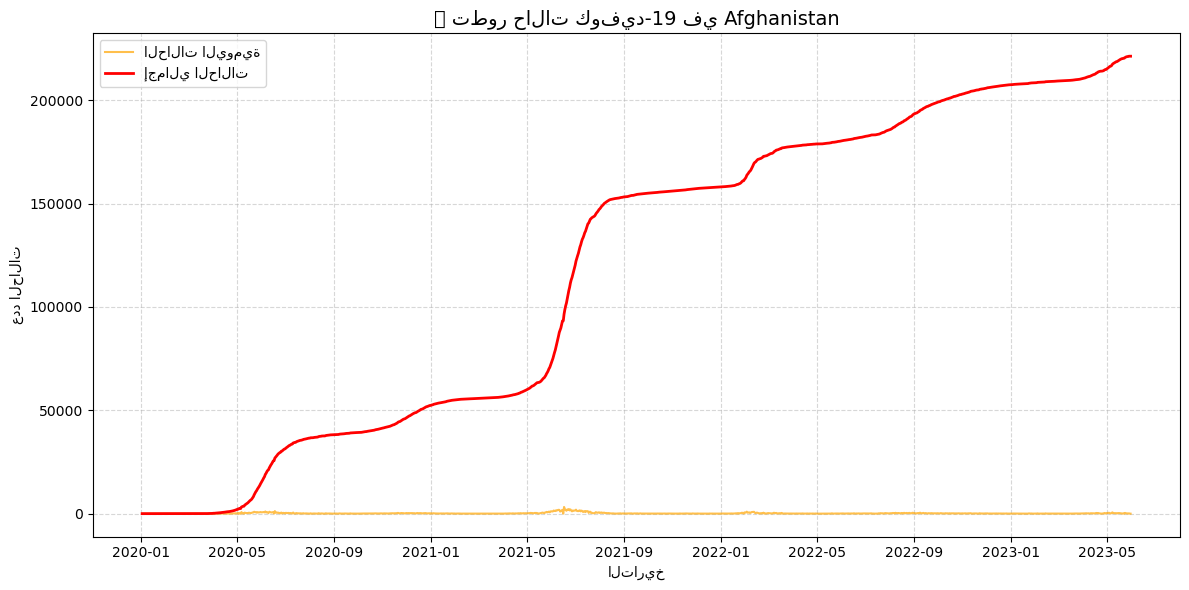

In [71]:
plt.figure(figsize=(12, 6))

# رسم منحنى الحالات اليومية
plt.plot(country_df['date'], country_df['new_cases'], label='الحالات اليومية', color='orange', alpha=0.7)

# رسم منحنى الحالات الإجمالية
plt.plot(country_df['date'], country_df['total_cases'], label='إجمالي الحالات', color='red', linewidth=2)

# تنسيق الرسم
plt.title(f"📈 تطور حالات كوفيد-19 في {country}", fontsize=14)
plt.xlabel("التاريخ")
plt.ylabel("عدد الحالات")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

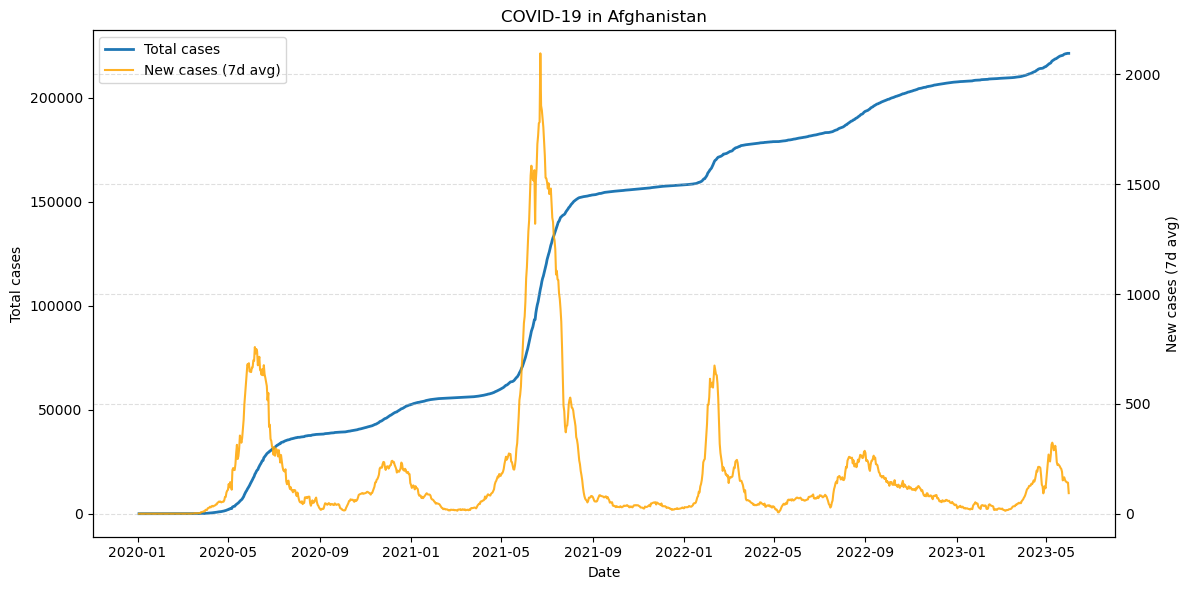

In [72]:
country = "Afghanistan"
cols = ['date', 'total_cases', 'new_cases']
country_df = df[df['location'] == country][cols].copy()

# 7-day rolling average for daily cases
country_df['new_cases_7d'] = country_df['new_cases'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Total cases on left y-axis
ax1.plot(country_df['date'], country_df['total_cases'],
         label='Total cases', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total cases')

# New cases on right y-axis
ax2 = ax1.twinx()
ax2.plot(country_df['date'], country_df['new_cases_7d'],
         label='New cases (7d avg)', color='orange', alpha=0.85)
ax2.set_ylabel('New cases (7d avg)')

# One legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'COVID-19 in {country}')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299979 entries, 0 to 299978
Data columns (total 37 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 299979 non-null  float64       
 5   new_cases                                   299979 non-null  float64       
 6   new_cases_smoothed                          291397 non-null  float64       
 7   total_deaths                                299979 non-null  float64       
 8   new_deaths                                  299979 non-null  float64      

In [74]:
df[('total_cases')].max()

103436829.0

In [75]:
row = df.loc[df['total_cases'].dropna().idxmax(), ['location','date','total_cases']]
row

location             United States
date           2023-05-14 00:00:00
total_cases            103436829.0
Name: 285104, dtype: object

In [76]:
latest = (df.sort_values(['location','date'])
            .dropna(subset=['total_cases'])
            .groupby('location', as_index=False)
            .tail(1))

top = latest.loc[latest['total_cases'].idxmax(), ['location','date','total_cases']]
top

location             United States
date           2023-06-02 00:00:00
total_cases            103436829.0
Name: 285123, dtype: object

In [77]:
latest.nlargest(5, 'total_cases')[['location','total_cases']]

,location,total_cases
285123,United States,103436829.0
53553,China,99268660.0
120687,India,44990278.0
90828,France,39035040.0
98302,Germany,38426308.0


### As shown United States has the highest total number of COVID-19 cases.

In [82]:
df[['location','total_cases']].max()

location          Zimbabwe
total_cases    103436829.0
dtype: object

In [83]:
latest.nsmallest(5, 'total_cases')[['location','total_cases']]

,location,total_cases
78378,England,0.0
116949,Hong Kong,0.0
153860,Macao,0.0
193707,North Korea,0.0
195643,Northern Cyprus,0.0


/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/3726991587.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


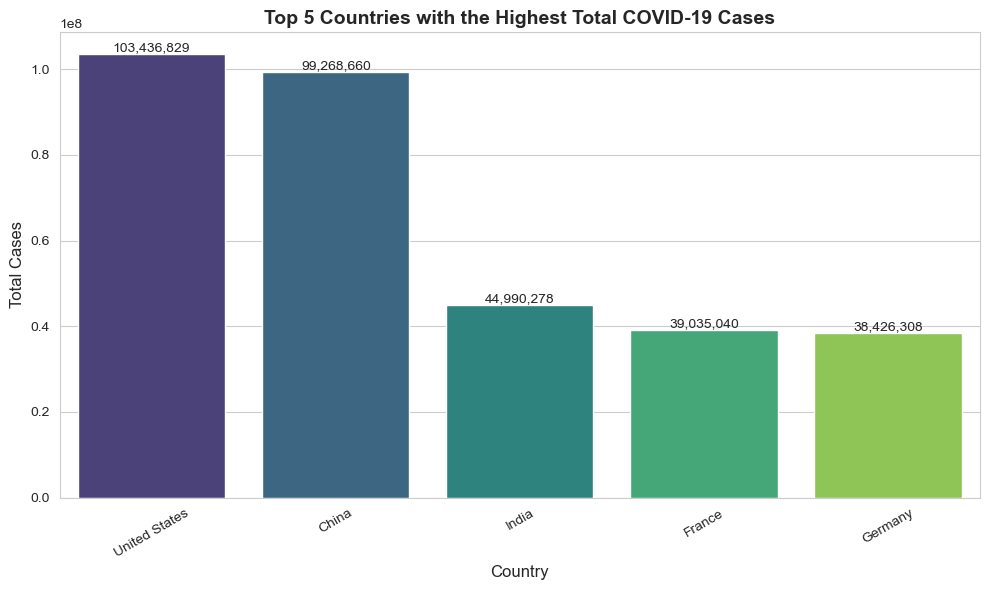

In [84]:
# 1️⃣ استخراج أعلى 5 دول من حيث عدد الحالات
top5 = latest.nlargest(5, 'total_cases')[['location', 'total_cases']]

# 2️⃣ إعداد الشكل (الستايل)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3️⃣ رسم مخطط الأعمدة
sns.barplot(
    x='location',
    y='total_cases',
    data=top5,
    palette='viridis'  # يمكنك تجربة "Blues", "magma", "coolwarm" ...
)

# 4️⃣ إضافة العناوين والتسميات
plt.title('Top 5 Countries with the Highest Total COVID-19 Cases', fontsize=14, weight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases', fontsize=12)

# 5️⃣ عرض القيم على الأعمدة
for i, value in enumerate(top5['total_cases']):
    plt.text(i, value, f'{int(value):,}', ha='center', va='bottom', fontsize=10)

# 6️⃣ تحسين العرض
plt.xticks(rotation=30)
plt.tight_layout()

# 7️⃣ عرض الرسم
plt.show()

/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/933706827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


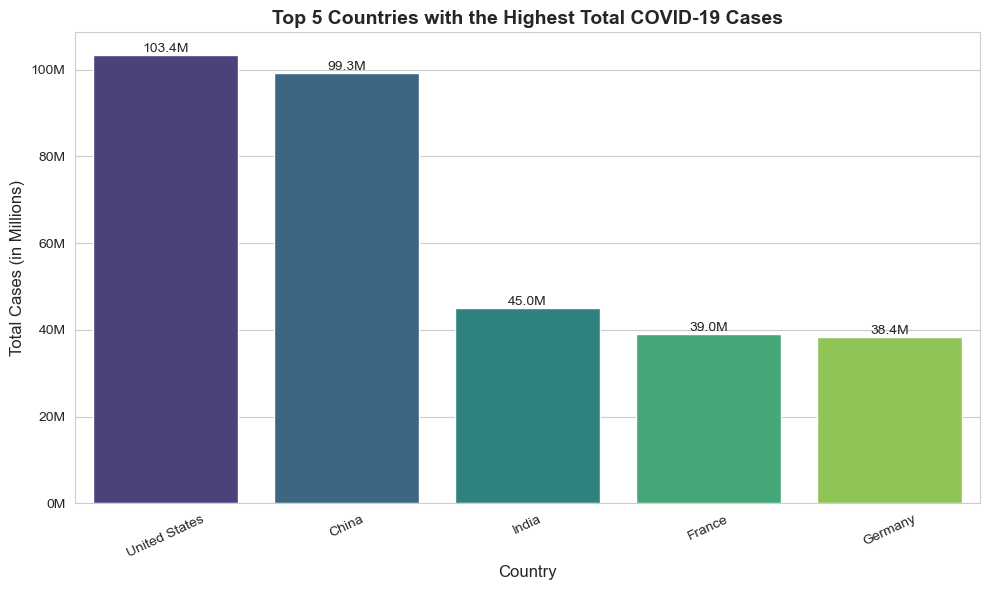

In [85]:
import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

# 1️⃣ استخراج أعلى 5 دول من حيث عدد الحالات الكلي
top5 = latest.nlargest(5, 'total_cases')[['location', 'total_cases']]

# 2️⃣ إعداد الشكل العام للمخطط
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3️⃣ رسم مخطط الأعمدة
sns.barplot(
    x='location',
    y='total_cases',
    data=top5,
    palette='viridis'
)

# 4️⃣ تنسيق الأرقام على المحور Y بالملايين
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

# 5️⃣ إضافة عناوين وتسميات المحاور
plt.title('Top 5 Countries with the Highest Total COVID-19 Cases', fontsize=14, weight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases (in Millions)', fontsize=12)

# 6️⃣ عرض القيم فوق الأعمدة
for i, value in enumerate(top5['total_cases']):
    plt.text(i, value, f'{value/1e6:.1f}M', ha='center', va='bottom', fontsize=10)

# 7️⃣ تحسين العرض
plt.xticks(rotation=25)
plt.tight_layout()

# 8️⃣ عرض المخطط
plt.show()

/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/1386392687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


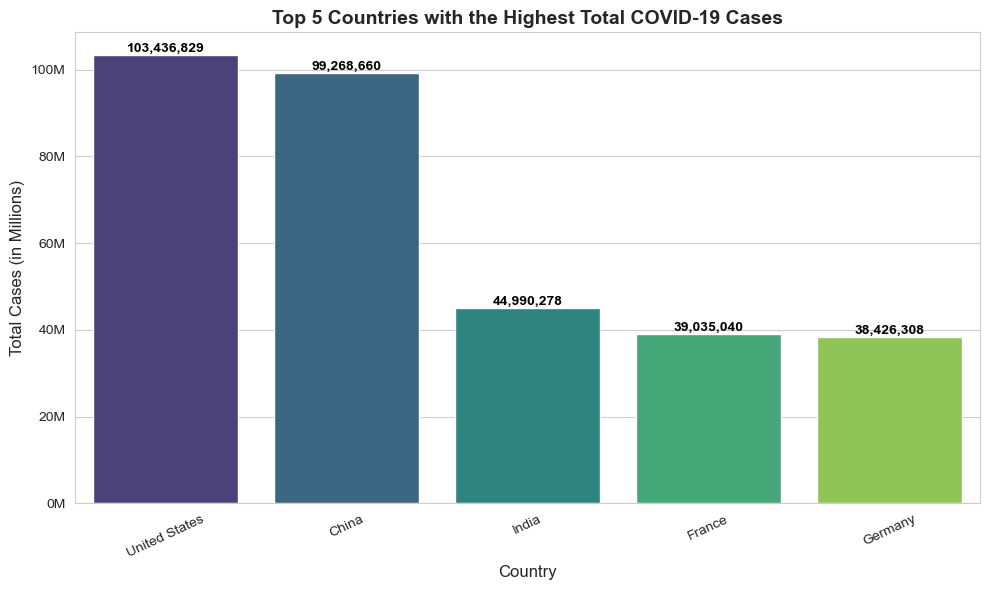

In [86]:

import matplotlib.ticker as mticker

# 1️⃣ استخراج أعلى 5 دول من حيث عدد الحالات
top5 = latest.nlargest(5, 'total_cases')[['location', 'total_cases']]

# 2️⃣ إعداد الشكل العام
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3️⃣ رسم المخطط بالأعمدة
sns.barplot(
    x='location',
    y='total_cases',
    data=top5,
    palette='viridis'
)

# 4️⃣ تنسيق المحور الرأسي (Y) بالملايين
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

# 5️⃣ إضافة العناوين والتسميات
plt.title('Top 5 Countries with the Highest Total COVID-19 Cases', fontsize=14, weight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases (in Millions)', fontsize=12)

# 6️⃣ كتابة القيم الكاملة فوق الأعمدة
for i, value in enumerate(top5['total_cases']):
    plt.text(
        i, value, f'{int(value):,}',  # صيغة رقمية كاملة مع الفواصل
        ha='center', va='bottom', fontsize=10, color='black', weight='bold'
    )

# 7️⃣ تحسين الشكل العام
plt.xticks(rotation=25)
plt.tight_layout()

# 8️⃣ عرض المخطط
plt.show()

In [91]:
# 1️⃣ ترتيب البيانات حسب الدولة والتاريخ
df_sorted = df.sort_values(['location', 'date'])

# 2️⃣ أخذ آخر صف (آخر تاريخ) لكل دولة
latest_cases = df_sorted.groupby('location', as_index=False).tail(1)

# 3️⃣ اختيار الأعمدة المهمة فقط
latest_cases = latest_cases[['location', 'date', 'total_cases']]

# 4️⃣ ترتيب النتائج تنازليًا حسب عدد الحالات
latest_cases = latest_cases.sort_values(by='total_cases')

# 5️⃣ عرض أول 10 دول كمثال
display(latest_cases.head(50))

,location,date,total_cases
196830,Northern Ireland,2023-05-31,0.0
78378,England,2023-05-24,0.0
296243,Western Sahara,2022-04-20,0.0
236607,Scotland,2023-05-29,0.0
262711,Taiwan,2023-04-27,0.0
116949,Hong Kong,2023-05-28,0.0
153860,Macao,2023-04-13,0.0
276406,Turkmenistan,2023-05-31,0.0
193707,North Korea,2023-05-31,0.0
294997,Wales,2023-05-31,0.0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299979 entries, 0 to 299978
Data columns (total 37 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    299979 non-null  object        
 1   continent                                   299979 non-null  object        
 2   location                                    299979 non-null  object        
 3   date                                        299979 non-null  datetime64[ns]
 4   total_cases                                 299979 non-null  float64       
 5   new_cases                                   299979 non-null  float64       
 6   new_cases_smoothed                          291397 non-null  float64       
 7   total_deaths                                299979 non-null  float64       
 8   new_deaths                                  299979 non-null  float64      

In [95]:
latest.nlargest(5, 'total_cases_per_million')[['location','total_cases_per_million']]

,location,total_cases_per_million
66004,Cyprus,737554.506
232938,San Marino,720837.044
38609,Brunei,682253.086
16196,Austria,679741.090
85848,Faeroe Islands,652484.139


In [97]:
latest.nlargest(5, 'total_deaths_per_million')[['location', 'total_deaths_per_million']]

,location,total_deaths_per_million
209281,Peru,6480.930
39857,Bulgaria,5659.430
33629,Bosnia and Herzegovina,5055.466
118194,Hungary,4894.403
194952,North Macedonia,4622.169


/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/303003539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


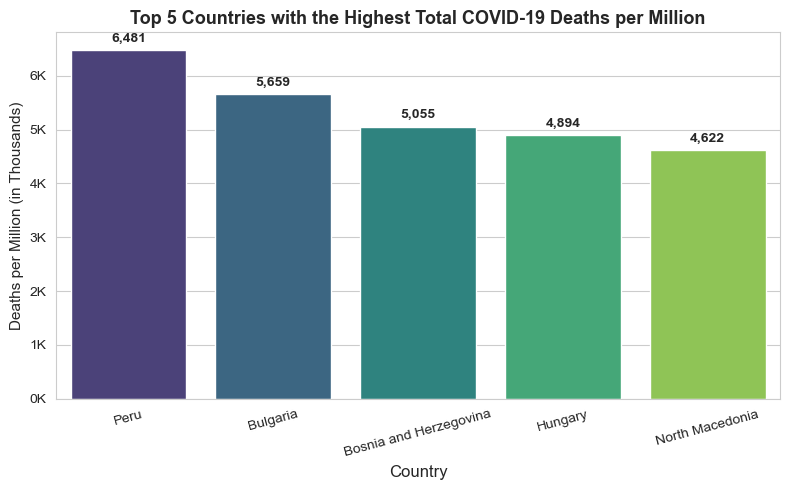

In [98]:
# استخراج أعلى 5 دول من حيث الوفيات لكل مليون
top_deaths = latest.nlargest(5, 'total_deaths_per_million')[['location', 'total_deaths_per_million']]

# إعداد الرسم
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_deaths,
    x='location',
    y='total_deaths_per_million',
    palette='viridis'
)

# إضافة الأرقام فوق كل عمود (كاملة)
for i, val in enumerate(top_deaths['total_deaths_per_million']):
    plt.text(i, val + 100, f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# تنسيق المحور الرأسي ليظهر بالألوف (K)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# العناوين والتنسيق
plt.title('Top 5 Countries with the Highest Total COVID-19 Deaths per Million', fontsize=13, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Deaths per Million (in Thousands)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [160]:
# حساب متوسط معدل التكاثر (لكل دولة في آخر يوم)
avg_reproduction_rate = latest['reproduction_rate'].mean()

# عرض النتيجة بتنسيق جميل
print(f"The average COVID-19 reproduction rate across all countries is approximately {avg_reproduction_rate:.2f}")

The average COVID-19 reproduction rate across all countries is approximately 0.49


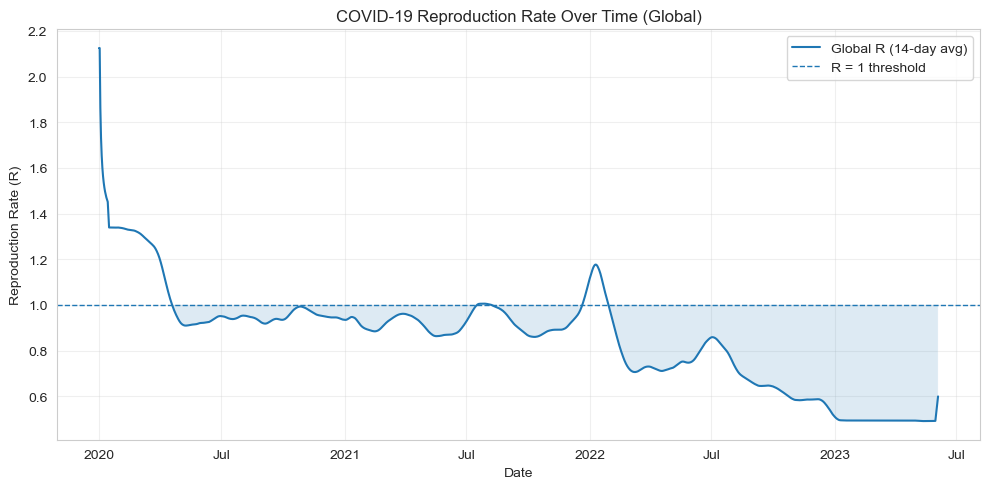

In [159]:
# === 1) الإعداد والتهيئة ===


# تأكد أن عمود التاريخ بصيغة datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# نحذف الصفوف التي بلا تاريخ
df = df.dropna(subset=['date'])

# === 2) حساب متوسط R العالمي لكل يوم ===
# (متوسط بسيط عبر الدول؛ NaN يتم تجاهلها تلقائياً)
daily_R = (
    df.groupby('date', as_index=True)['reproduction_rate']
      .mean()
      .sort_index()
)

# تنعيم 14 يوماً لتقليل الضوضاء
daily_R_smoothed = daily_R.rolling(14, min_periods=1).mean()

# === 3) الرسم ===
fig, ax = plt.subplots(figsize=(10, 5))

# المنحنى العالمي
ax.plot(daily_R_smoothed.index, daily_R_smoothed.values, label='Global R (14-day avg)')

# خط مرجعي عند R=1
ax.axhline(1.0, linestyle='--', linewidth=1, label='R = 1 threshold')

# تظليل المناطق تحت/فوق 1 لسهولة القراءة
ax.fill_between(daily_R_smoothed.index,
                daily_R_smoothed.values, 1.0,
                where=(daily_R_smoothed.values < 1.0),
                interpolate=True, alpha=0.15)

# تهيئة المحاور والعناوين
ax.set_title('COVID-19 Reproduction Rate Over Time (Global)')
ax.set_xlabel('Date')
ax.set_ylabel('Reproduction Rate (R)')
ax.grid(True, alpha=0.3)

# تنسيق محور التاريخ
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.tight_layout()
plt.show()


In [104]:
# 1️⃣ تحديد العمود المستهدف
col = 'new_vaccinations_smoothed_per_million'

# 2️⃣ حذف القيم المفقودة
latest_vax = latest.dropna(subset=[col])

# 3️⃣ استخراج أعلى 5 دول حسب معدل التطعيم
top5_vax = latest_vax.nlargest(5, col)[['location', col]]

# 4️⃣ عرض النتائج
display(top5_vax)

,location,new_vaccinations_smoothed_per_million
270181,Tokelau,17961.0
224223,Saint Helena,17960.0
210526,Philippines,16119.0
247816,Solomon Islands,15745.0
276406,Turkmenistan,11734.0


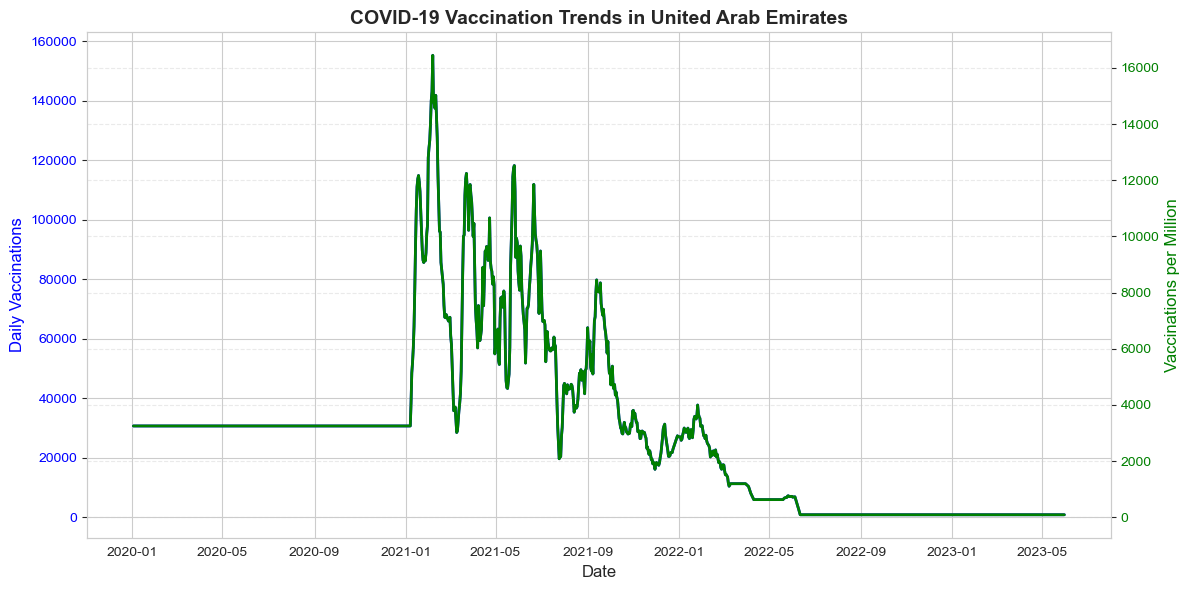

In [105]:
# اختر الدولة التي تريد تحليلها
country = "United Arab Emirates"

# استخراج بيانات الدولة
cols = ['date', 'new_vaccinations_smoothed', 'new_vaccinations_smoothed_per_million']
country_vax = df[df['location'] == country][cols].dropna()

# إنشاء الشكل والمحورين
fig, ax1 = plt.subplots(figsize=(12, 6))

# المحور الأول: عدد التطعيمات الفعلية (جرعات يومية)
ax1.plot(country_vax['date'], country_vax['new_vaccinations_smoothed'],
         color='blue', linewidth=2, label='Daily Vaccinations (Smoothed)')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Daily Vaccinations', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# المحور الثاني: معدل التطعيم لكل مليون نسمة
ax2 = ax1.twinx()
ax2.plot(country_vax['date'], country_vax['new_vaccinations_smoothed_per_million'],
         color='green', linewidth=2, label='Vaccinations per Million')
ax2.set_ylabel('Vaccinations per Million', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

# العنوان والتفاصيل
plt.title(f'COVID-19 Vaccination Trends in {country}', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

/var/folders/c1/7d0tvnf132l3hmvspvzb19m80000gn/T/ipykernel_39371/1602689816.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_vax, x='location', y=col, palette='crest')


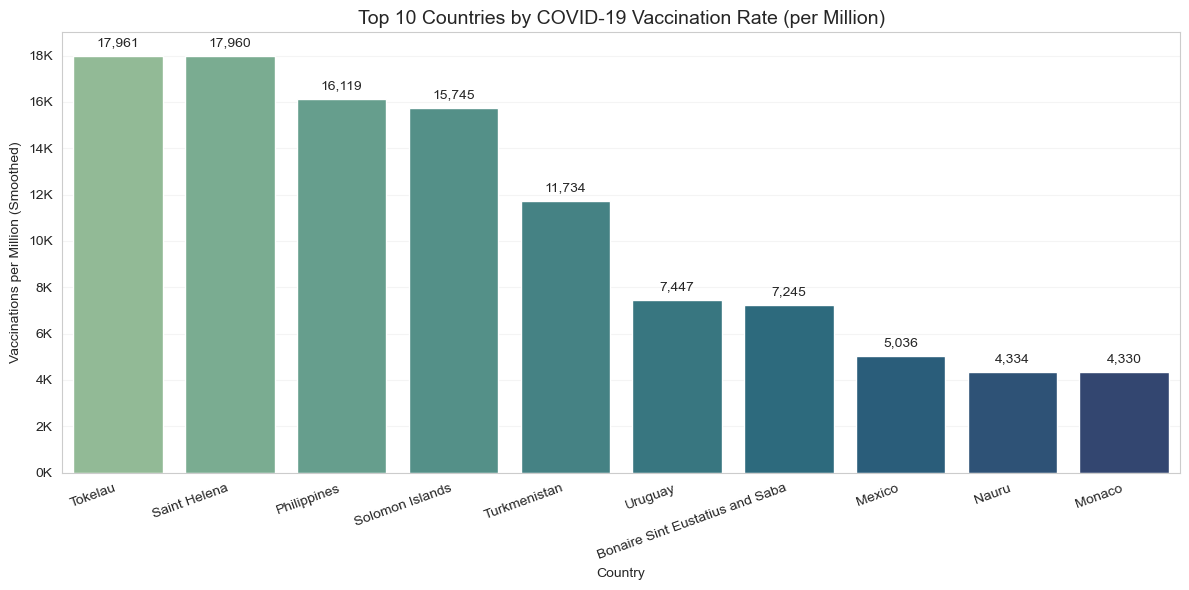

In [107]:


# 1) احصل على أحدث صف لكل دولة
latest = (
    df.sort_values(['location', 'date'])
      .dropna(subset=['location'])                    # احتياطًا
      .groupby('location', as_index=False).tail(1)    # آخر تاريخ لكل دولة
)

# 2) العمود المطلوب (معدل التطعيم لكل مليون – مُنعّم)
col = 'new_vaccinations_smoothed_per_million'

# 3) تخلّص من القيم المفقودة ثم استخرج أعلى 10 دول
latest_vax = latest.dropna(subset=[col])
top10_vax  = latest_vax.nlargest(10, col)[['location', col]].copy()

# 4) الرسم
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top10_vax, x='location', y=col, palette='crest')

# 5) تثبيت مواقع علامات المحور كل 2000 بالضبط + تنسيقها إلى K
ax.yaxis.set_major_locator(mticker.MultipleLocator(2000))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# 6) اجعل الحدّ الأعلى أعلى من أكبر قيمة بهامش 1000
ymax = top10_vax[col].max()
ax.set_ylim(0, math.ceil(ymax/1000)*1000 + 1000)

# 7) إظهار القيم الكاملة فوق كل عمود (مع فواصل الآلاف)
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f'{value:,.0f}', 
                (p.get_x() + p.get_width()/2, value),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=10)

# 8) تحسينات شكلية
ax.set_title('Top 10 Countries by COVID-19 Vaccination Rate (per Million)', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Vaccinations per Million (Smoothed)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [110]:
# 1️⃣ اختيار الدولة
country = "Afghanistan"

# 2️⃣ تصفية البيانات للدولة فقط
country_df = df[df['location'] == country]

# 3️⃣ تحديد الصف الذي يحتوي على أعلى عدد حالات جديدة
max_row = country_df.loc[country_df['new_cases'].idxmax(), ['date', 'new_cases']]

# 4️⃣ عرض النتيجة
print(f"The highest number of new daily cases in {country} was {int(max_row['new_cases']):,} on {max_row['date'].date()}.")

The highest number of new daily cases in Afghanistan was 3,243 on 2021-06-17.


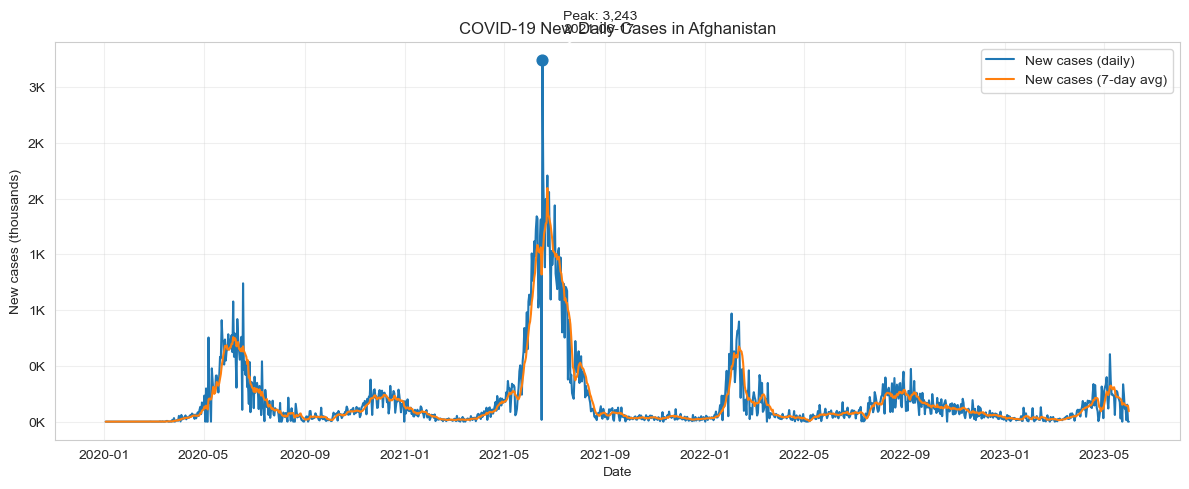

The highest number of new daily cases in Afghanistan was 3,243 on 2021-06-17.


In [113]:
# 1) تصفية بيانات أفغانستان
country = "Afghanistan"
afg = df[df["location"] == country].copy()

# (اختياري) لو التاريخ ليس datetime:
# afg["date"] = pd.to_datetime(afg["date"])

# 2) إيجاد اليوم الأعلى في الإصابات الجديدة
idx_max = afg["new_cases"].idxmax()
peak_date = afg.loc[idx_max, "date"]
peak_value = afg.loc[idx_max, "new_cases"]

# (اختياري) حساب متوسط متحرك 7 أيام لتنعيم السلسلة
afg["new_cases_7d"] = afg["new_cases"].rolling(7, min_periods=1).mean()

# 3) الرسم
plt.figure(figsize=(12, 5))

# السلسلة اليومية
plt.plot(afg["date"], afg["new_cases"], label="New cases (daily)")

# السلسلة المنعّمة 7 أيام (اختياري للتوضيح)
plt.plot(afg["date"], afg["new_cases_7d"], label="New cases (7-day avg)")

# تمييز نقطة الذروة وتعليقها
plt.scatter([peak_date], [peak_value], s=60, zorder=5)
plt.annotate(
    f"Peak: {int(peak_value):,}\n{pd.to_datetime(peak_date).date()}",
    xy=(peak_date, peak_value),
    xytext=(15, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10
)

# تنسيق المحور الرأسي بالآلاف
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1_000)}K"))

plt.title(f"COVID-19 New Daily Cases in {country}")
plt.xlabel("Date")
plt.ylabel("New cases (thousands)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# طباعة النتيجة نصياً أيضاً
print(f"The highest number of new daily cases in {country} was {int(peak_value):,} on {pd.to_datetime(peak_date).date()}.")

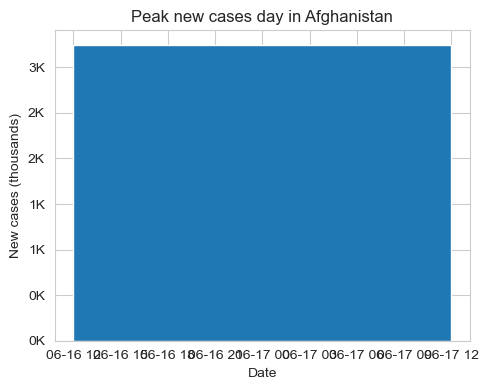

Peak = 3,243 on 2021-06-17


In [114]:

country = "Afghanistan"
afg = df[df["location"] == country].copy()
idx = afg["new_cases"].idxmax()
peak_date = pd.to_datetime(afg.loc[idx, "date"])
peak_val  = afg.loc[idx, "new_cases"]

plt.figure(figsize=(5,4))
plt.bar([peak_date], [peak_val], width=1)   # عمود وحيد
plt.title(f"Peak new cases day in {country}")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1_000)}K"))
plt.ylabel("New cases (thousands)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Peak = {int(peak_val):,} on {peak_date.date()}")

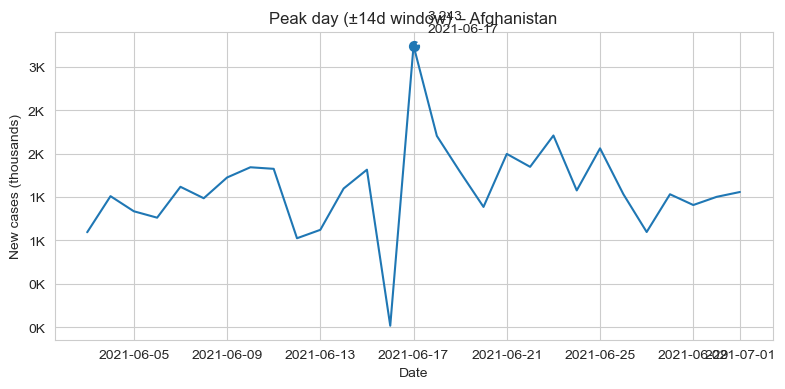

In [115]:


country = "Afghanistan"
afg = df[df["location"] == country].copy()
afg["date"] = pd.to_datetime(afg["date"])

idx = afg["new_cases"].idxmax()
peak_date = afg.loc[idx, "date"]
peak_val  = afg.loc[idx, "new_cases"]

win = afg[(afg["date"] >= peak_date - pd.Timedelta(days=14)) &
          (afg["date"] <= peak_date + pd.Timedelta(days=14))].copy()

plt.figure(figsize=(8,4))
plt.plot(win["date"], win["new_cases"])
plt.scatter([peak_date], [peak_val], s=50, zorder=3)
plt.annotate(f"{int(peak_val):,}\n{peak_date.date()}",
             xy=(peak_date, peak_val), xytext=(10,10),
             textcoords="offset points", arrowprops=dict(arrowstyle="->", lw=1))
plt.title(f"Peak day (±14d window) – {country}")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1_000)}K"))
plt.ylabel("New cases (thousands)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

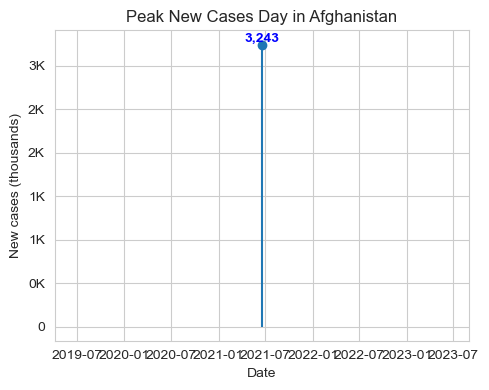

The highest number of new daily cases in Afghanistan was 3,243 on 2021-06-17.


In [119]:

# الدولة
country = "Afghanistan"
afg = df[df["location"] == country].copy()
afg["date"] = pd.to_datetime(afg["date"])

# تحديد يوم الذروة
idx = afg["new_cases"].idxmax()
peak_date = afg.loc[idx, "date"]
peak_val = afg.loc[idx, "new_cases"]

# رسم عمود واحد
plt.figure(figsize=(5,4))
plt.stem([peak_date], [peak_val])

# تنسيق الأرقام على المحور الرأسي
def k_formatter(x, _):
    if x == 0:
        return "0"
    return f"{int(x/1_000)}K"

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))

# تسميات وعنوان
plt.title(f"Peak New Cases Day in {country}")
plt.ylabel("New cases (thousands)")
plt.xlabel("Date")

# إظهار الرقم فوق العمود
plt.text(peak_date, peak_val, f"{int(peak_val):,}", 
         ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')

plt.tight_layout()
plt.show()

print(f"The highest number of new daily cases in {country} was {int(peak_val):,} on {peak_date.date()}.")

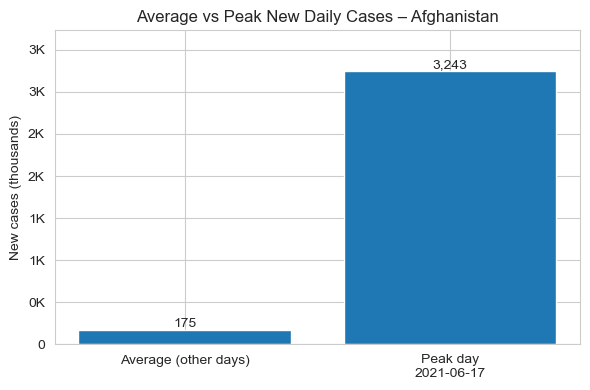

Average (other days): 175
Peak day: 3,243 on 2021-06-17


In [120]:

# اختر الدولة
country = "Afghanistan"

# تجهيز بيانات الدولة
afg = df[df["location"] == country].copy()
afg["date"] = pd.to_datetime(afg["date"])

# تحديد يوم الذروة وقيمته
idx = afg["new_cases"].idxmax()
peak_date = afg.loc[idx, "date"]
peak_val  = float(afg.loc[idx, "new_cases"])

# متوسط الأيام الأخرى (باستثناء يوم الذروة)
avg_others = float(afg.loc[afg.index != idx, "new_cases"].mean())

# بيانات الرسم
labels = ["Average (other days)", f"Peak day\n{peak_date.date()}"]
values = [avg_others, peak_val]

# رسم عمودين
plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

# تنسيق المحور الرأسي بالآلاف K
def k_formatter(x, _):
    if x == 0:
        return "0"
    return f"{int(x/1_000)}K"
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))

# كتابة القيم فوق الأعمدة (بالأرقام الكاملة)
for b, v in zip(bars, values):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(),
             f"{int(round(v)):,}", ha="center", va="bottom", fontsize=10)

plt.title(f"Average vs Peak New Daily Cases – {country}")
plt.ylabel("New cases (thousands)")
plt.ylim(0, max(values)*1.15)  # مساحة علوية لوسم الأرقام
plt.tight_layout()
plt.show()

print(f"Average (other days): {avg_others:,.0f}")
print(f"Peak day: {peak_val:,.0f} on {peak_date.date()}")

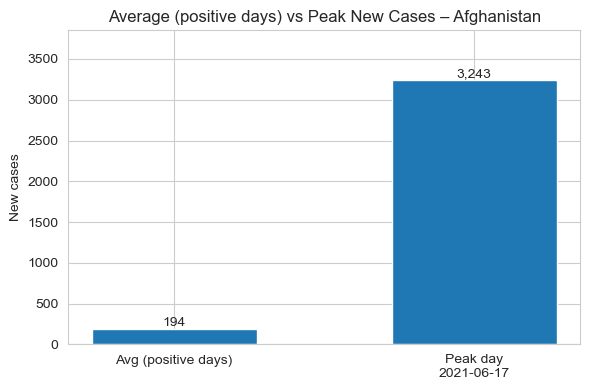

Average (positive days): 194
Peak day: 3,243 on 2021-06-17


In [121]:
# اختر الدولة
country = "Afghanistan"

# فلترة بيانات الدولة
afg = df[df["location"] == country].copy()
afg["date"] = pd.to_datetime(afg["date"])

# يوم الذروة وقيمته
idx_peak = afg["new_cases"].idxmax()
peak_date = afg.loc[idx_peak, "date"]
peak_val  = float(afg.loc[idx_peak, "new_cases"])

# متوسط الأيام ذات القيم الموجبة فقط (تجاهل الصفر و NaN)
pos_cases = afg.loc[afg["new_cases"] > 0, "new_cases"]
avg_nonzero = float(pos_cases.mean()) if not pos_cases.empty else 0.0

# بيانات الرسم
labels = ["Avg (positive days)", f"Peak day\n{peak_date.date()}"]
values = [avg_nonzero, peak_val]

# إعداد محور y بخطوة 500: 0, 500, 1000, 1500, ...
y_max = max(values)
y_top = int(np.ceil(y_max / 500.0) * 500)  # تقريبه لأعلى مضاعف لـ 500
yticks = np.arange(0, y_top + 1, 500)

# الرسم
plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, width=0.55)

# تعيين تدريجات المحور الرأسي المطلوبة
plt.yticks(yticks)
plt.ylim(0, y_top * 1.1 if y_top > 0 else 1)  # هامش بسيط علوي

# كتابة القيم كاملة فوق كل عمود (مع فواصل الآلاف)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{int(round(v)):,}", ha="center", va="bottom", fontsize=10)

plt.title(f"Average (positive days) vs Peak New Cases – {country}")
plt.ylabel("New cases")
plt.xlabel("")
plt.tight_layout()
plt.show()

print(f"Average (positive days): {avg_nonzero:,.0f}")
print(f"Peak day: {peak_val:,.0f} on {peak_date.date()}")

,continent,total_cases,total_deaths,death_to_case_ratio
0,Africa,13090531.0,258948.0,0.019781
5,South America,68630314.0,1355943.0,0.019757
3,North America,124328495.0,1601656.0,0.012882
2,Europe,249520469.0,2064903.0,0.008275
1,Asia,297617681.0,1632734.0,0.005486
4,Oceania,14176629.0,27147.0,0.001915


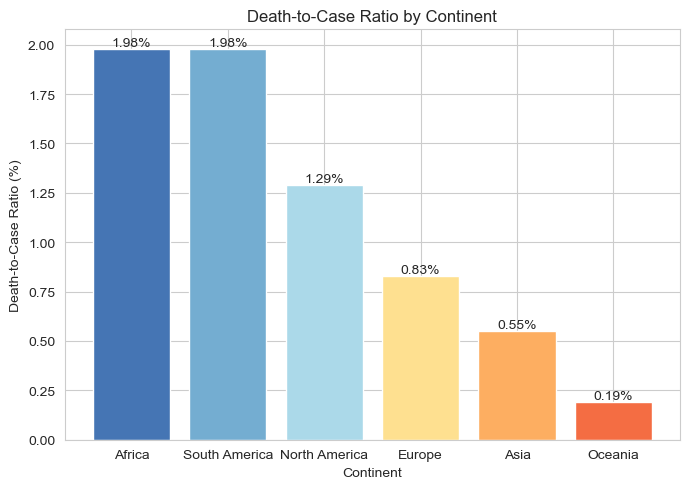

🌍 The continent with the highest death-to-case ratio is **Africa**, with a ratio of 1.98%.



In [123]:

# 1️⃣ استخراج آخر صف لكل دولة (للحصول على القيم النهائية)
latest_by_country = (
    df.sort_values(['location', 'date'])
      .groupby('location', as_index=False)
      .tail(1)
)

# 2️⃣ تجميع البيانات حسب القارة
continent_summary = (
    latest_by_country
    .groupby('continent')[['total_cases', 'total_deaths']]
    .sum(min_count=1)  # يتجاهل NaN
    .reset_index()
)

# 3️⃣ حساب نسبة الوفيات إلى الحالات (death-to-case ratio)
continent_summary['death_to_case_ratio'] = (
    continent_summary['total_deaths'] / continent_summary['total_cases']
)

# 4️⃣ ترتيب النتائج تنازليًا حسب النسبة
continent_summary = continent_summary.sort_values(
    'death_to_case_ratio', ascending=False
)

# 5️⃣ عرض النتائج
display(continent_summary)

# 6️⃣ رسم بياني يوضّح نسبة الوفيات إلى الحالات في كل قارة
plt.figure(figsize=(7,5))
bars = plt.bar(
    continent_summary['continent'],
    continent_summary['death_to_case_ratio'] * 100,  # كنسبة مئوية
    color=['#4575b4', '#74add1', '#abd9e9', '#fee090', '#fdae61', '#f46d43']
)

# كتابة النسب فوق الأعمدة
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha='center', va='bottom', fontsize=10
    )

plt.title("Death-to-Case Ratio by Continent")
plt.ylabel("Death-to-Case Ratio (%)")
plt.xlabel("Continent")
plt.tight_layout()
plt.show()

# 7️⃣ تحديد القارة صاحبة أعلى نسبة وفيات
top_continent = continent_summary.iloc[0]
print(f"🌍 The continent with the highest death-to-case ratio is **{top_continent['continent']}**, "
      f"with a ratio of {top_continent['death_to_case_ratio']*100:.2f}%.\n")

In [131]:
egypt_latest = df[df['location'] == 'Egypt'].sort_values('date').tail(1)                        
display(egypt_latest[['location','date','total_cases','total_deaths']])

,location,date,total_cases,total_deaths
75972,Egypt,2023-05-31,516023.0,24830.0


In [132]:
# تأكد أن df يحتوي على أحدث صف لكل دولة
latest_by_country = (
    df.sort_values(['location','date'])
      .groupby('location', as_index=False)
      .tail(1)
)

# 1️⃣ معدل الوفيات العالمي
world_deaths = latest_by_country['total_deaths'].sum(skipna=True)
world_cases  = latest_by_country['total_cases'].sum(skipna=True)
world_rate = (world_deaths / world_cases) * 100

# 2️⃣ معدل الوفيات في قارة إفريقيا
africa_df = latest_by_country[latest_by_country['continent'] == 'Africa']
africa_deaths = africa_df['total_deaths'].sum(skipna=True)
africa_cases  = africa_df['total_cases'].sum(skipna=True)
africa_rate = (africa_deaths / africa_cases) * 100

# 3️⃣ معدل الوفيات في مصر
egypt_df = latest_by_country[latest_by_country['location'] == 'Egypt']
egypt_deaths = egypt_df['total_deaths'].iloc[0]
egypt_cases  = egypt_df['total_cases'].iloc[0]
egypt_rate = (egypt_deaths / egypt_cases) * 100

# 4️⃣ طباعة النتائج
print(f"🌍 Global death rate: {world_rate:.2f}%")
print(f"🌍 Africa death rate: {africa_rate:.2f}%")
print(f"🇪🇬 Egypt death rate: {egypt_rate:.2f}%")

🌍 Global death rate: 0.90%
🌍 Africa death rate: 1.98%
🇪🇬 Egypt death rate: 4.81%


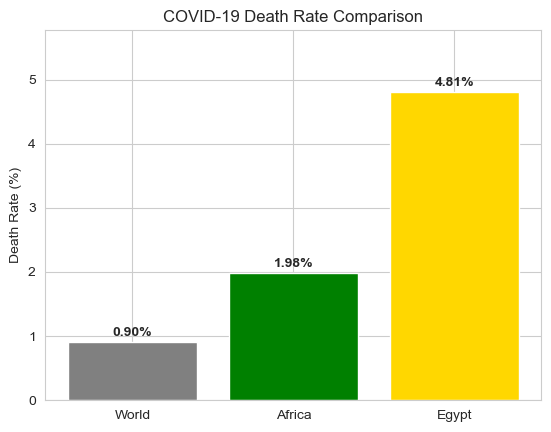

In [133]:

labels = ['World', 'Africa', 'Egypt']
values = [world_rate, africa_rate, egypt_rate]

plt.bar(labels, values, color=['gray','green','gold'])
plt.ylabel('Death Rate (%)')
plt.title('COVID-19 Death Rate Comparison')
plt.ylim(0, max(values)*1.2)

for i, v in enumerate(values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

🌍 Global death rate: 0.90%
🌍 Africa death rate: 1.98%
🇪🇬 Egypt death rate: 4.81%


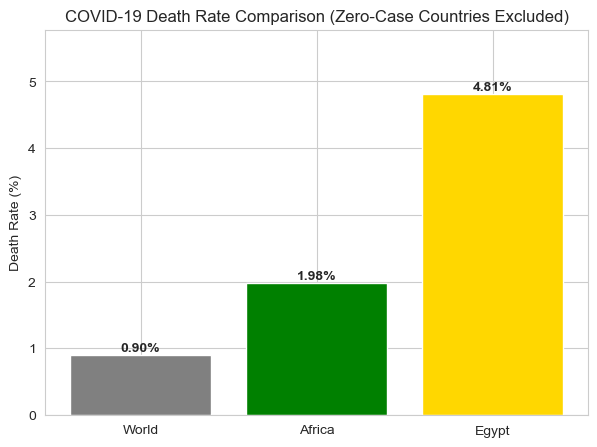

In [134]:
# أحدث صف لكل دولة
latest_by_country = (
    df.sort_values(['location', 'date'])
      .groupby('location', as_index=False)
      .tail(1)
)

# تجاهل الدول التي ليس لديها أي حالات مؤكدة
latest_nonzero = latest_by_country[latest_by_country['total_cases'] > 0].copy()

# 1️⃣ المعدل العالمي
world_deaths = latest_nonzero['total_deaths'].sum(skipna=True)
world_cases  = latest_nonzero['total_cases'].sum(skipna=True)
world_rate = (world_deaths / world_cases) * 100

# 2️⃣ المعدل القاري (أفريقيا)
africa_df = latest_nonzero[latest_nonzero['continent'] == 'Africa']
africa_deaths = africa_df['total_deaths'].sum(skipna=True)
africa_cases  = africa_df['total_cases'].sum(skipna=True)
africa_rate = (africa_deaths / africa_cases) * 100

# 3️⃣ المعدل الخاص بمصر
egypt_df = latest_nonzero[latest_nonzero['location'] == 'Egypt']
egypt_deaths = egypt_df['total_deaths'].iloc[0]
egypt_cases  = egypt_df['total_cases'].iloc[0]
egypt_rate = (egypt_deaths / egypt_cases) * 100

# 4️⃣ طباعة النتائج
print(f"🌍 Global death rate: {world_rate:.2f}%")
print(f"🌍 Africa death rate: {africa_rate:.2f}%")
print(f"🇪🇬 Egypt death rate: {egypt_rate:.2f}%")

# 5️⃣ رسم بياني للمقارنة
labels = ['World', 'Africa', 'Egypt']
values = [world_rate, africa_rate, egypt_rate]

plt.figure(figsize=(7,5))
bars = plt.bar(labels, values, color=['gray','green','gold'])
plt.ylabel('Death Rate (%)')
plt.title('COVID-19 Death Rate Comparison (Zero-Case Countries Excluded)')

for i, v in enumerate(values):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.ylim(0, max(values) * 1.2)
plt.show()

In [135]:
df['total_cases'].isna().sum()

np.int64(0)

In [136]:
# 🔍 التحقق من الدول التي total_cases = 0
zero_cases = latest_by_country[latest_by_country['total_cases'] == 0]

# عدد هذه الدول
count_zero = zero_cases.shape[0]

# النسبة المئوية مقارنة بإجمالي عدد الدول
total_countries = latest_by_country.shape[0]
percentage_zero = (count_zero / total_countries) * 100

print(f"عدد الدول التي لديها صفر حالات: {count_zero}")
print(f"وتمثل نسبة {percentage_zero:.2f}% من إجمالي الدول في قاعدة البيانات.")

# عرض قائمة هذه الدول لمعرفة من هي
display(zero_cases[['location', 'continent', 'total_cases', 'total_deaths']])

عدد الدول التي لديها صفر حالات: 11
وتمثل نسبة 4.53% من إجمالي الدول في قاعدة البيانات.


,location,continent,total_cases,total_deaths
78378,England,Europe,0.0,0.0
116949,Hong Kong,Asia,0.0,0.0
153860,Macao,Asia,0.0,0.0
193707,North Korea,Asia,0.0,0.0
195643,Northern Cyprus,Asia,0.0,0.0
196830,Northern Ireland,Europe,0.0,0.0
236607,Scotland,Europe,0.0,0.0
262711,Taiwan,Asia,0.0,0.0
276406,Turkmenistan,Asia,0.0,0.0
294997,Wales,Europe,0.0,0.0


In [137]:
# آخر صف لكل دولة
latest_by_country = (
    df.sort_values(['location','date'])
      .groupby('location', as_index=False)
      .tail(1)
)

# فلترة دول حقيقية فقط (لها قارة) والتأكد من الأعمدة المطلوبة
latest_by_country = latest_by_country[latest_by_country['continent'].notna()].copy()

# الشروط: تنمية بشرية مرتفعة ومعدل وفيات قلب منخفض
filtered = latest_by_country[
    (latest_by_country['human_development_index'] > 0.8) &
    (latest_by_country['cardiovasc_death_rate'] < 200)
][['location','continent','human_development_index','cardiovasc_death_rate']].sort_values('cardiovasc_death_rate')

# عرض النتائج
print("Countries with HDI > 0.8 and Cardiovascular Death Rate < 200:")
display(filtered)

Countries with HDI > 0.8 and Cardiovascular Death Rate < 200:


,location,continent,human_development_index,cardiovasc_death_rate
131895,Japan,Asia,0.919,79.370
251551,South Korea,Asia,0.916,85.998
90828,France,Europe,0.901,86.060
242836,Singapore,Asia,0.938,92.243
128157,Israel,Asia,0.919,93.320
126912,Isle of Man,Europe,0.919,93.320
254041,Spain,Europe,0.904,99.403
260268,Switzerland,Europe,0.955,99.739
46082,Canada,North America,0.929,105.599
13701,Aruba,North America,0.944,107.791


In [138]:

# 1) لقطة أحدث صف لكل دولة
latest_by_country = (
    df.sort_values(['location','date'])
      .groupby('location', as_index=False)
      .tail(1)
)

# نحتفظ بالدول الحقيقية فقط (لها قارة معروفة)
latest = latest_by_country[latest_by_country['continent'].notna()].copy()

# 2) دالة لحساب "معدل وفيات كوفيد" المجمع مع استبعاد الدول ذات الحالات = 0
def covid_death_rate(sub):
    s = sub[(sub['total_cases'] > 0) & (sub['total_deaths'].notna()) & (sub['total_cases'].notna())]
    deaths = s['total_deaths'].sum()
    cases  = s['total_cases'].sum()
    return np.nan if cases == 0 else deaths / cases

# 3) تعريف المجموعات
high_dev_low_cvd = latest[(latest['human_development_index'] > 0.8) &
                          (latest['cardiovasc_death_rate'] < 200)]

low_dev_high_cvd = latest[(latest['human_development_index'] < 0.5) &
                          (latest['cardiovasc_death_rate'] >= 200)]

# 4) حساب المعدلات
world_rate = covid_death_rate(latest)
grp_A_rate = covid_death_rate(high_dev_low_cvd)
grp_B_rate = covid_death_rate(low_dev_high_cvd)

# 5) طباعة مقارنة واضحة
def fmt(p): return "NA" if pd.isna(p) else f"{p*100:.2f}%"

print("COVID-19 Death-to-Case Ratios (micro-average):")
print(f" - World:                    {fmt(world_rate)}  (all countries)")
print(f" - HDI>0.8 & CVD<200:        {fmt(grp_A_rate)}  (high dev / low cardio)")
print(f" - HDI<0.5 & CVD>=200:       {fmt(grp_B_rate)}  (low dev / high cardio)")

COVID-19 Death-to-Case Ratios (micro-average):
 - World:                    0.90%  (all countries)
 - HDI>0.8 & CVD<200:        0.65%  (high dev / low cardio)
 - HDI<0.5 & CVD>=200:       1.62%  (low dev / high cardio)


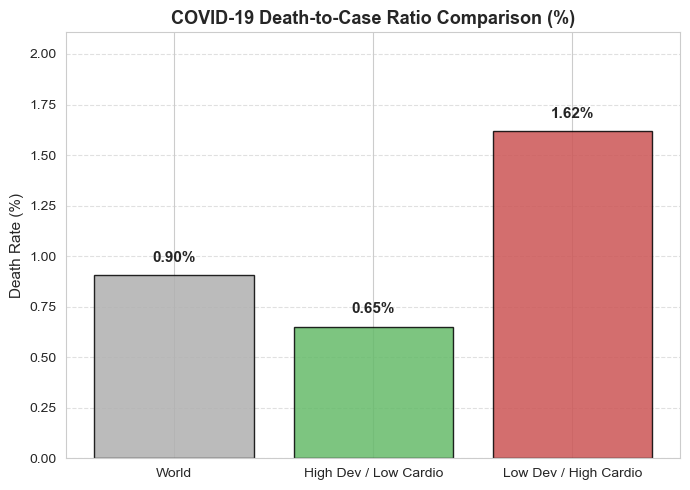

In [144]:


# البيانات التي حسبناها
labels = ['World', 'High Dev / Low Cardio', 'Low Dev / High Cardio']
values = [world_rate * 100, grp_A_rate * 100, grp_B_rate * 100]  # تحويل إلى نسبة مئوية
# ألوان ناعمة (pastel tones)
colors = ['#b0b0b0', '#66bb6a', '#cc5555']  # رمادي فاتح، أخضر ناعم، أحمر باهت


# إنشاء الشكل
plt.figure(figsize=(7,5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', alpha=0.85)

# إضافة العنوان والمحاور
plt.title('COVID-19 Death-to-Case Ratio Comparison (%)', fontsize=13, fontweight='bold')
plt.ylabel('Death Rate (%)', fontsize=11)
plt.ylim(0, max(values) * 1.3)  # مساحة إضافية للأرقام فوق الأعمدة

# إضافة القيم فوق الأعمدة
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}%", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# تحسين المظهر
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [148]:
# تأكد أن عمود التاريخ بصيغة datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# تصفية القارتين المطلوبتين فقط
continents = ['Africa', 'Europe']
df_time = df[df['continent'].isin(continents)][['continent', 'date', 'new_cases_smoothed']].copy()

# التحقق من أول الصفوف بعد التصفية
display(df_time.head(10))

,continent,date,new_cases_smoothed
1245,Europe,2020-01-03,0.0
1246,Europe,2020-01-04,0.0
1247,Europe,2020-01-05,0.0
1248,Europe,2020-01-06,0.0
1249,Europe,2020-01-07,0.0
1250,Europe,2020-01-08,0.0
1251,Europe,2020-01-09,0.0
1252,Europe,2020-01-10,0.0
1253,Europe,2020-01-11,0.0
1254,Europe,2020-01-12,0.0


In [154]:
# تجميع البيانات حسب القارة والتاريخ
continent_daily = (
    df_time
    .groupby(['continent', 'date'], as_index=False)['new_cases_smoothed']
    .sum()   # يمكن استخدام .mean() بدلاً من sum حسب نوع التحليل
)

# عرض بعض النتائج
display(continent_daily)

,continent,date,new_cases_smoothed
0,Africa,2020-01-03,0.000
1,Africa,2020-01-04,0.000
2,Africa,2020-01-05,0.000
3,Africa,2020-01-06,0.000
4,Africa,2020-01-07,0.000
...,...,...,...
2489,Europe,2023-05-31,8512.144
2490,Europe,2023-06-01,3381.000
2491,Europe,2023-06-02,3381.000
2492,Europe,2023-06-03,3277.571


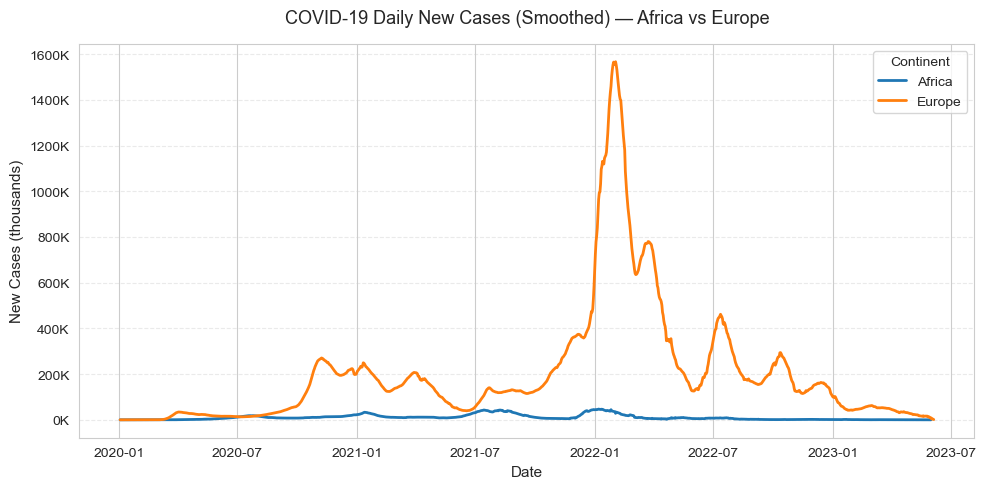

In [150]:


# 1️⃣ نرسم الرسم البياني لكل قارة بخط مختلف
plt.figure(figsize=(10, 5))

for continent in continent_daily['continent'].unique():
    subset = continent_daily[continent_daily['continent'] == continent]
    plt.plot(subset['date'], subset['new_cases_smoothed'], label=continent, linewidth=2)

# 2️⃣ تنسيق الشكل العام
plt.title("COVID-19 Daily New Cases (Smoothed) — Africa vs Europe", fontsize=13, pad=15)
plt.xlabel("Date", fontsize=11)
plt.ylabel("New Cases (thousands)", fontsize=11)

# تحويل المحور الرأسي إلى آلاف
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# خطوط خفيفة على المحور الأفقي والعمودي
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 3️⃣ إظهار وسيلة الإيضاح (القارات)
plt.legend(title='Continent')

# 4️⃣ تحسين العرض
plt.tight_layout()
plt.show()

In [151]:
continent_daily.groupby('continent')['new_cases_smoothed'].max()

continent
Africa      46976.144
Europe    1566685.143
Name: new_cases_smoothed, dtype: float64

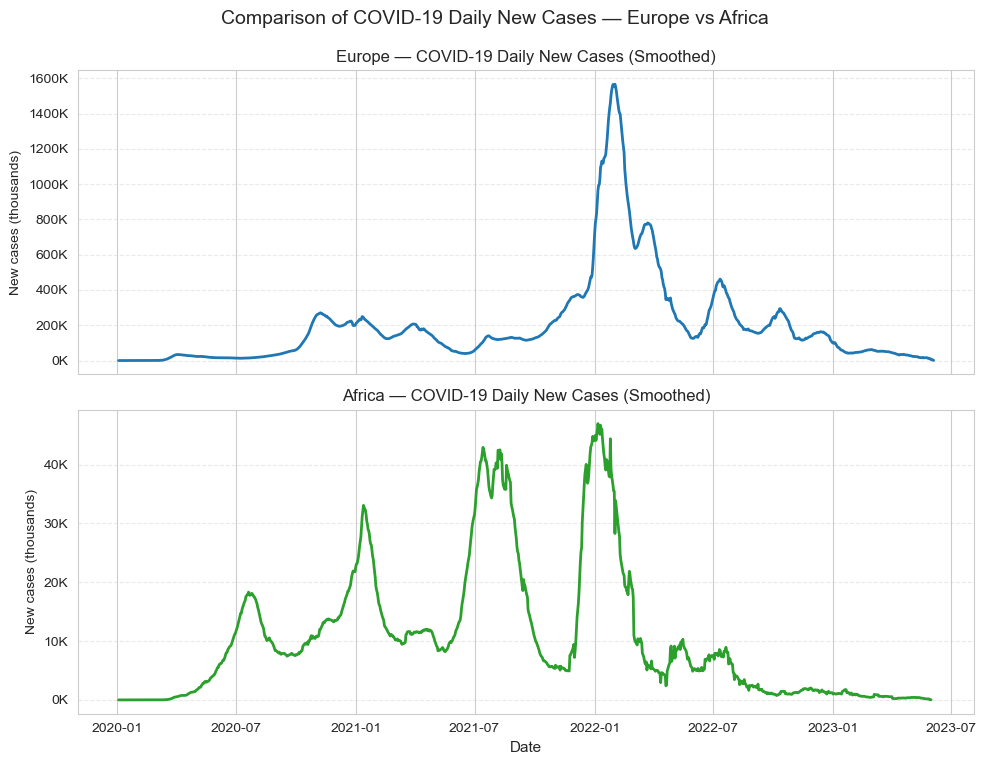

In [152]:

# إنشاء الشكل العام بمخططين رأسيين (2 صف، 1 عمود)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# تكرار الرسم لكل قارة في subplot مختلف
for i, continent in enumerate(['Europe', 'Africa']):
    subset = continent_daily[continent_daily['continent'] == continent]
    
    axes[i].plot(subset['date'], subset['new_cases_smoothed'], linewidth=2, color='tab:blue' if continent == 'Europe' else 'tab:green')
    axes[i].set_title(f"{continent} — COVID-19 Daily New Cases (Smoothed)", fontsize=12)
    axes[i].set_ylabel("New cases (thousands)", fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    
    # تحويل المحور إلى الآلاف
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# عنوان عام للمخططين
plt.suptitle("Comparison of COVID-19 Daily New Cases — Europe vs Africa", fontsize=14, y=0.95)
plt.xlabel("Date", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()